# Data Processing


In [26]:
# Load csv as pandas dataframe
import pandas as pd

# Load csv as pandas dataframe
cleanedPatternDf = pd.read_csv('Datasets/scraped_blog_tables.csv')

cleanedPatternDf['Start'] = pd.to_datetime(cleanedPatternDf['Start'])
cleanedPatternDf['End'] = pd.to_datetime(cleanedPatternDf['End'])

cleanedPatternDf

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
0,ACN,"Triangle, symmetrical",1,2019-12-19,2020-01-30,IT Services
1,ADS,Broadening top,-1,2019-12-13,2020-01-24,Information Services
2,AVY,Triple bottom,1,2019-12-03,2020-01-27,Packaging and Container
3,CMTL,Dead-cat bounce,-1,2020-01-29,2020-01-29,Telecom. Equipment
4,CSOD,Pipe top,-1,2020-01-13,2020-01-21,E-Commerce
...,...,...,...,...,...,...
10780,TPR,Head-and-shoulders top,0,2025-02-06,2025-02-26,Apparel
10781,TGT,"Double Top, Eve and Adam",0,2025-01-10,2025-01-28,Retail Store
10782,TDOC,"Double Top, Adam and Adam",0,2025-02-10,2025-02-14,Healthcare Information
10783,TDY,"Double Bottom, Adam and Adam",0,2025-02-14,2025-02-24,Aerospace/Defense


## Remove data of missing data Symbols


In [27]:
# get the csv file names exept the extension in the folder OHLC data 
import os
from os import listdir
from os.path import isfile, join
onlyfiles = [f for f in listdir('Datasets/OHLC data') if isfile(join('Datasets/OHLC data', f))]
onlyfiles = [f.split('.')[0] for f in onlyfiles]
print(onlyfiles)

#  now remove any row that contain a Symbol that is not in the list of csv file names from the filteredPatternDf dataframe
cleanedPatternDf = cleanedPatternDf[cleanedPatternDf['Symbol'].isin(onlyfiles)]
cleanedPatternDf.head()

['A', 'AA', 'AAPL', 'ABC', 'ABM', 'ABT', 'ACGL', 'ACIW', 'ACN', 'ADBE', 'ADM', 'ADP', 'ADS', 'ADSK', 'ADTN', 'AEE', 'AEIS', 'AEL', 'AEO', 'AEP', 'AES', 'AFG', 'AFL', 'AGO', 'AIG', 'AIZ', 'AJRD', 'AKAM', 'ALB', 'ALGT', 'ALK', 'ALKS', 'ALL', 'ALRM', 'AMAT', 'AMD', 'AME', 'AMED', 'AMGN', 'AMN', 'AMTD', 'AMWD', 'AMZN', 'ANET', 'ANF', 'ANIK', 'ANTM', 'AON', 'APA', 'APD', 'APH', 'APOG', 'AR', 'ARCB', 'ARW', 'ASGN', 'ASH', 'ASNA', 'ATO', 'ATR', 'ATSG', 'AVA', 'AVNT', 'AVY', 'AWI', 'AXDX', 'AXE', 'AXP', 'AXS', 'AYI', 'AYX', 'AZTA', 'BA', 'BAH', 'BALL', 'BAX', 'BBBY', 'BBW', 'BBY', 'BCO', 'BCPC', 'BECN', 'BERY', 'BFH', 'BG', 'BIG', 'BIIB', 'BIO', 'BKH', 'BKNG', 'BLDR', 'BLL', 'BMI', 'BMRN', 'BMY', 'BOOM', 'BOOT', 'BOTZ', 'BR', 'BRC', 'BRKR', 'BRKS', 'BSET', 'BSX', 'BZH', 'CACI', 'CAG', 'CAL', 'CALM', 'CBT', 'CCK', 'CCRN', 'CDAY', 'CDNS', 'CE', 'CENX', 'CF', 'CGNX', 'CHD', 'CHKP', 'CI', 'CIEN', 'CINF', 'CL', 'CLF', 'CLGX', 'CLNE', 'CLR', 'CLS', 'CLX', 'CMCO', 'CMI', 'CMTL', 'CNA', 'CNC', 'CNO', 

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
0,ACN,"Triangle, symmetrical",1,2019-12-19,2020-01-30,IT Services
1,ADS,Broadening top,-1,2019-12-13,2020-01-24,Information Services
2,AVY,Triple bottom,1,2019-12-03,2020-01-27,Packaging and Container
3,CMTL,Dead-cat bounce,-1,2020-01-29,2020-01-29,Telecom. Equipment
4,CSOD,Pipe top,-1,2020-01-13,2020-01-21,E-Commerce


## Filter for the selected patterns


In [28]:
from utils.formatAndPreprocessNewPatterns import filter_to_get_selected_patterns

filteredPatternDf = filter_to_get_selected_patterns(cleanedPatternDf)

# get the list of unique Chart Patterns in Chart Pattern column
uniqueChartPatterns = filteredPatternDf['Chart Pattern'].unique()

# make new directory to save the filtered data 
if not os.path.exists('Datasets/New_pattern_set_data'):
    os.makedirs('Datasets/New_pattern_set_data')

filteredPatternDf.to_csv('Datasets/New_pattern_set_data/filteredPatternDf.csv', index=False)

print(uniqueChartPatterns)
filteredPatternDf 

['Triangle, symmetrical' 'Double Bottom' 'Double Top'
 'Flag, high and tight' 'Head-and-shoulders top'
 'Head-and-shoulders bottom']


,Symbol,Chart Pattern,BullishBearish,Start,End,Industry
0,ACN,"Triangle, symmetrical",1,2019-12-19,2020-01-30,IT Services
14,TPX,Double Bottom,1,2020-01-06,2020-01-27,Furn/Home Furnishings
19,BSET,Double Top,-1,2019-12-20,2020-01-22,Furn/Home Furnishings
20,BBW,"Flag, high and tight",1,2019-12-12,2020-01-23,Retail (Special Lines)
22,CIEN,"Triangle, symmetrical",1,2019-12-13,2020-01-23,Telecom. Equipment
...,...,...,...,...,...,...
10780,TPR,Head-and-shoulders top,0,2025-02-06,2025-02-26,Apparel
10781,TGT,Double Top,0,2025-01-10,2025-01-28,Retail Store
10782,TDOC,Double Top,0,2025-02-10,2025-02-14,Healthcare Information
10783,TDY,Double Bottom,0,2025-02-14,2025-02-24,Aerospace/Defense


In [29]:
filteredPatternDf_un_aug = filteredPatternDf.copy()

## Width Augment


In [30]:
import numpy as np
from utils.formatAndPreprocessNewPatterns import width_augmentation

min_aug_len = 3
aug_len_fraction = 0.5
np.random.seed(69)

filteredPatternDf_w_aug = width_augmentation(filteredPatternDf_un_aug, min_aug_len, aug_len_fraction, make_duplicates = False, keep_original = False)

Performing width augmentation...


Processing:   0%|          | 0/4545 [00:00<?, ?it/s]

e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\formatAndPreprocessNewPatterns.py:384: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  filteredPattern_width_aug_df = pd.concat([filteredPattern_width_aug_df, pd.DataFrame([new_row])], ignore_index=True)
Processing:   1%|          | 23/4545 [00:00<01:35, 47.41it/s]

No data for WIRE between 2019-11-11 00:00:00 and 2020-01-09 00:00:00
No data for ERA between 2019-12-18 00:00:00 and 2020-01-06 00:00:00
No data for ABC between 2020-02-12 00:00:00 and 2020-02-21 00:00:00
No data for CREE between 2020-01-06 00:00:00 and 2020-02-21 00:00:00


Processing:   1%|          | 43/4545 [00:00<01:25, 52.85it/s]

...

No data for CDAY between 2025-02-05 00:00:00 and 2025-02-12 00:00:00


Processing:  97%|█████████▋| 4391/4545 [00:47<00:01, 121.92it/s]

No data for CDAY between 2025-01-06 00:00:00 and 2025-01-28 00:00:00


Processing: 100%|██████████| 4545/4545 [00:49<00:00, 92.56it/s] 

No data for FISV between 2025-02-20 00:00:00 and 2025-03-03 00:00:00


## Width augment data switch


In [31]:
filteredPatternDf = filteredPatternDf_un_aug
# filteredPatternDf =filteredPatternDf_w_aug

## Add No Pattern Data


In [32]:
oob_no_pattern_df = pd.read_csv('Datasets/VanilaDataset/oob_no_pattern_stats_df.csv', index_col=0)
oob_no_pattern_df["Avg_Prob"] = oob_no_pattern_df['oob_sum'] / oob_no_pattern_df['oob_count']
sorted_df = oob_no_pattern_df.sort_values(by='Avg_Prob', ascending=False)
top_500_instances = sorted_df.head(1000)
no_pattern_all_df = pd.read_csv('Datasets/VanilaDataset/no_pattern_10000_df.csv', index_col=0)
# Read the CSV file
instance_index_mapping_df = pd.read_csv('Datasets/VanilaDataset/instance_index_mapping_df.csv', index_col=0)
# Convert back to dictionary
instance_index_mapping = dict(zip(instance_index_mapping_df['Instance'], instance_index_mapping_df['Index']))

In [33]:
top_500_instances = top_500_instances.index

no_pattern_df =no_pattern_all_df.loc[top_500_instances]
no_pattern_df

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry,Pattern_Length
Instance,,,,,,,
3852,PRU,No Pattern,0,2023-12-22,2024-01-17,Insurance (Life),16
6089,CLX,No Pattern,-1,2021-09-17,2021-09-25,Household Products,6
6928,VMI,No Pattern,0,2023-03-22,2023-04-04,Metal Fabricating,10
1890,NFG,No Pattern,0,2023-10-20,2023-11-02,Natural Gas (Diversified),10
6676,AXDX,No Pattern,1,2020-09-25,2020-10-28,Medical Services,24
...,...,...,...,...,...,...,...
6416,MYGN,No Pattern,-1,2021-06-22,2021-07-01,Biotechnology,8
2933,BIG,No Pattern,0,2023-08-28,2023-09-05,Retail Store,0
3573,SMG,No Pattern,-1,2021-11-24,2021-12-24,Chemical (Basic),21


In [34]:
# concatenate the two dataframes
final_pattern_df = pd.concat([filteredPatternDf, no_pattern_df], ignore_index=True)
final_pattern_df_w_aug =  pd.concat([filteredPatternDf_w_aug, no_pattern_df], ignore_index=True)

final_pattern_df.to_csv('Datasets/New_pattern_set_data/final_pattern_df.csv', index=True)
final_pattern_df_w_aug.to_csv('Datasets/New_pattern_set_data/final_pattern_df_w_aug.csv', index=True)

# convert Start and End columns to datetime
final_pattern_df['Start'] = pd.to_datetime(final_pattern_df['Start'])
final_pattern_df['End'] = pd.to_datetime(final_pattern_df['End'])

final_pattern_df_w_aug['Start'] = pd.to_datetime(final_pattern_df_w_aug['Start'])
final_pattern_df_w_aug['End'] = pd.to_datetime(final_pattern_df_w_aug['End'])

final_pattern_df

,Symbol,Chart Pattern,BullishBearish,Start,End,Industry,Pattern_Length
0,ACN,"Triangle, symmetrical",1,2019-12-19,2020-01-30,IT Services,NaN
1,TPX,Double Bottom,1,2020-01-06,2020-01-27,Furn/Home Furnishings,NaN
2,BSET,Double Top,-1,2019-12-20,2020-01-22,Furn/Home Furnishings,NaN
3,BBW,"Flag, high and tight",1,2019-12-12,2020-01-23,Retail (Special Lines),NaN
4,CIEN,"Triangle, symmetrical",1,2019-12-13,2020-01-23,Telecom. Equipment,NaN
...,...,...,...,...,...,...,...
5540,MYGN,No Pattern,-1,2021-06-22,2021-07-01,Biotechnology,8.0
5541,BIG,No Pattern,0,2023-08-28,2023-09-05,Retail Store,0.0
5542,SMG,No Pattern,-1,2021-11-24,2021-12-24,Chemical (Basic),21.0
5543,CRH,No Pattern,1,2022-08-17,2022-08-29,Cement and Aggregates,9.0


In [35]:
# get the number of each chart pattern
pattern_counts = final_pattern_df['Chart Pattern'].value_counts()
# Print the counts
print(pattern_counts)

Chart Pattern
Double Bottom                1550
Double Top                   1445
No Pattern                   1000
Triangle, symmetrical         562
Head-and-shoulders top        388
Head-and-shoulders bottom     361
Flag, high and tight          239
Name: count, dtype: int64


### Test Train Split


In [36]:
# split the data into train and test set with 80% of the data in the train set
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(final_pattern_df, test_size=0.2, random_state=42)

train_df_w_aug, test_df_w_aug = train_test_split(final_pattern_df_w_aug, test_size=0.2, random_state=42)

In [37]:
from utils.formatAndPreprocessNewPatterns import dataset_format

train_df_ohlc = dataset_format(train_df)
test_df_ohlc = dataset_format(test_df)

train_df_w_aug_ohlc = dataset_format(train_df_w_aug)
test_df_w_aug_ohlc = dataset_format(test_df_w_aug)

Missing symbols:  {'SWN'}
Processing 4434 tasks in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 352 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 4160 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 4434 out of 4434 | elapsed:   12.6s finished


Total tasks: 4434, Successful: 4269
Instance counter final value: 4269
Number of successful instances: 4269


e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\formatAndPreprocessNewPatterns.py:279: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='ffill', inplace=True)


Processing 1109 tasks in parallel...


...

e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\formatAndPreprocessNewPatterns.py:279: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='ffill', inplace=True)


Missing symbols:  {'SWN'}
Processing 1074 tasks in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 512 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 1074 out of 1074 | elapsed:    2.3s finished


Total tasks: 1074, Successful: 1068
Instance counter final value: 1068
Number of successful instances: 1068


e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\formatAndPreprocessNewPatterns.py:279: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='ffill', inplace=True)


In [38]:
train_df_ohlc

Open      High       Low     Close    Volume  Pattern
Instance Time                                                           
0        0     0.537634  0.551075  0.016127  0.161289  0.347412        1
         1     0.287634  0.553763  0.228494  0.513441  0.259018        1
         2     0.540322  0.865591  0.497311  0.604839  0.274569        1
         3     0.556453  0.760754  0.529570  0.752689  0.000000        1
         4     0.836022  0.967742  0.776882  0.913978  0.274384        1
...                 ...       ...       ...       ...       ...      ...
4268     12    0.497364  0.707381  0.445518  0.597540  0.548931        4
         13    0.574692  0.713532  0.504393  0.654657  0.250281        4
         14    0.647627  0.895430  0.647627  0.724077  0.082677        4
         15    0.764499  0.797012  0.361160  0.367311  0.494938        4
         16    0.372583  0.586116  0.273286  0.584358  0.257593        4

[67547 rows x 6 columns]

In [39]:
# save the train and test dataframes to csv files
train_df_ohlc.to_csv('Datasets/New_pattern_set_data/train_df_ohlc.csv', index=True)
test_df_ohlc.to_csv('Datasets/New_pattern_set_data/test_df_ohlc.csv', index=True)

train_df_w_aug_ohlc.to_csv('Datasets/New_pattern_set_data/train_df_w_aug_ohlc.csv', index=True)
test_df_w_aug_ohlc.to_csv('Datasets/New_pattern_set_data/test_df_w_aug_ohlc.csv', index=True)

train_df.to_csv('Datasets/New_pattern_set_data/train_df.csv', index=True)
test_df.to_csv('Datasets/New_pattern_set_data/test_df.csv', index=True)

train_df_w_aug.to_csv('Datasets/New_pattern_set_data/train_df_w_aug.csv', index=True)
test_df_w_aug.to_csv('Datasets/New_pattern_set_data/test_df_w_aug.csv', index=True)

## Train data aug


In [15]:
import numpy as np
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
from utils.formatAndPreprocessNewPatterns import get_patetrn_name_by_encoding



# Define a linear trend function (y = a*x + b)
def linear_trend(x, slope=0.1, intercept=0):
    return slope * x + intercept

# Define a non-linear (quadratic) trend function (y = a*x^2 + b*x + c)
def quadratic_trend(x, a=0.001, b=0.01, c=0):
    return a * x**2 + b * x + c

# Define a sine wave trend function
def sine_trend(x, amplitude=0.02, frequency=0.05 ):
    return amplitude * np.sin(frequency * x)

def plot_trend_function(x_values, trend, trend_function_name):
    """Plot the trend function"""
    plt.figure(figsize=(3, 2))
    plt.plot(x_values, trend, label=f'{trend_function_name}')
    plt.title('Trend Function Plot')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_original_and_augmented_data(original_data, augmented_data):
    """Plot original and augmented data as candlestick charts"""
    # Prepare original and noisy data for plotting (OHLC only)
    original_data_for_plot = original_data[['Open', 'High', 'Low', 'Close']].reset_index(drop=True)
    augmented_data_for_plot = augmented_data[['Open', 'High', 'Low', 'Close']].reset_index(drop=True)

    # Create two subplots to compare original and noisy data
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Create a DatetimeIndex for the plots (ensure it matches the number of rows in the data)
    date_range = pd.date_range(start='2024-01-01', periods=len(original_data_for_plot), freq='D')

    # Assign the index to the original and noisy data for plotting
    original_data_for_plot.index = date_range
    augmented_data_for_plot.index = date_range

    # Plot the original data
    mpf.plot(original_data_for_plot, type='candle', ax=axes[0], style='yahoo', volume=False)
    axes[0].grid(True)  # Enable gridlines
    axes[0].set_title("Original OHLC Candlestick Chart")

    # Plot the noisy data (augmented with trend)
    mpf.plot(augmented_data_for_plot, type='candle', ax=axes[1], style='yahoo', volume=False)
    axes[1].grid(True)  # Enable gridlines
    axes[1].set_title("Augmented OHLC Candlestick Chart with Trend")

    # Show the comparison plots
    plt.tight_layout()
    plt.show()

def traindata_augment(Dataset):
    # Define the number of samples to generate
    n_total_samples = 1000
    # Create a counter for generating new first-level indices
    new_first_level_counter = Dataset.index.get_level_values(0).max() + 1

    # Loop through the unique chart patterns in the Dataset
    for pattern in Dataset['Pattern'].unique():
        # Filter the Dataset for the current pattern
        pattern_data = Dataset[Dataset['Pattern'] == pattern]

        # Get the unique values from the first level of the multi-index
        unique_first_level_index = pattern_data.index.get_level_values(0).unique()
        
        # get two random samples from the unique first level index
        instances_to_plot = np.random.choice(unique_first_level_index, 2, replace=False)

        # Set the number of augmented samples to create
        n_samples = n_total_samples - len(unique_first_level_index)

        # Loop through the number of samples to generate
        for i in range(n_samples):
            # Randomly select a section of the DataFrame based on the first-level index
            random_first_level_value = np.random.choice(unique_first_level_index)
            random_section = pattern_data.loc[(random_first_level_value, slice(None)), :]

            # Get the difference between max and min of Close column
            diff = random_section['Close'].max() - random_section['Close'].min()
            adjusted_diff = np.log(1 + diff)  # Adding 1 to avoid log(0)

            # Introduce randomness into the noise level
            noise_level = adjusted_diff * (0.08 + np.random.uniform(-0.01, 0.01))  # Adding random factor
            sub_noise_level = adjusted_diff * (0.01 + np.random.uniform(-0.004, 0.004))  # Adding random factor

            x_values = np.arange(len(random_section))

            # Randomly select a trend function
            trend_function = np.random.choice([linear_trend, quadratic_trend, sine_trend])

            # Modify the trend function parameters based on price range and random factors
            if trend_function == linear_trend:
                slope = np.random.uniform(0.005, 0.05) * adjusted_diff * (0.4 + np.random.uniform(-0.01, 0.01))   # Slope depends on price difference
                trend = linear_trend(x_values, slope=slope)
                if (random_first_level_value in instances_to_plot) :
                    print('slope:', slope)
            elif trend_function == quadratic_trend:
                a = np.random.uniform(0.00001, 0.0005) * adjusted_diff * (0.4 + np.random.uniform(-0.01, 0.01))   # Quadratic coefficient scaled by diff
                b = np.random.uniform(0.001, 0.01) * adjusted_diff
                trend = quadratic_trend(x_values, a=a, b=b)
                if (random_first_level_value in instances_to_plot) :
                    print('a:', a, 'b:', b)
            else:  # sine_trend
                amplitude = np.random.uniform(0.05, 1.2) * adjusted_diff * (0.4 + np.random.uniform(-0.01, 0.01))   # Amplitude depends on price difference
                frequency = np.random.uniform(0.01, 1)
                trend = sine_trend(x_values, amplitude=amplitude, frequency=frequency)
                if (random_first_level_value in instances_to_plot) :
                    print('amplitude:', amplitude, 'frequency:', frequency)



            # Add random noise (minor noise level) for variation in individual OHLC points
            noise = np.random.normal(0, sub_noise_level, random_section[['Open', 'High', 'Low', 'Close', 'Volume']].shape)
            noisy_data = random_section[['Open', 'High', 'Low', 'Close', 'Volume']] + noise

            # Add consistent noise across the same row (major noise level)
            row_noise = np.random.normal(0, noise_level, random_section[['Open']].shape)
            noisy_data['Open'] = random_section['Open'] + row_noise.squeeze()
            noisy_data['High'] = random_section['High'] + row_noise.squeeze()
            noisy_data['Low'] = random_section['Low'] + row_noise.squeeze()
            noisy_data['Close'] = random_section['Close'] + row_noise.squeeze()
            # noisy_data['Adj Close'] = random_section['Adj Close'] + row_noise.squeeze()
            noisy_data['Volume'] = random_section['Volume'] + row_noise.squeeze()

            # Add the trend equally to all OHLC columns
            noisy_data['Open'] += trend
            noisy_data['High'] += trend
            noisy_data['Low'] += trend
            noisy_data['Close'] += trend
            # noisy_data['Adj Close'] += trend
            noisy_data['Volume'] += trend  # You can adjust the impact of the trend on Volume if needed

            # Assign new first-level index to the noisy_data
            new_first_level_index = pd.MultiIndex.from_product([[new_first_level_counter], random_section.index.get_level_values(1)], names=['Index', 'Date'])
            noisy_data.index = new_first_level_index

            # Increment the first-level counter for the next sample
            new_first_level_counter += 1

            # Visualize the original and noisy data using candlestick charts
            if (random_first_level_value in instances_to_plot) :
                print(f"\nSelected Chart Pattern: {get_patetrn_name_by_encoding(pattern)}")
                print(f"\nSelected Trend Function: {trend_function.__name__}")
                plot_trend_function(x_values, trend, trend_function.__name__)
                plot_original_and_augmented_data(random_section, noisy_data)
                # pop the instance from the instances_to_plot
                instances_to_plot = instances_to_plot[instances_to_plot != random_first_level_value]
            
            # add Pattern column to the noisy data
            noisy_data['Pattern'] = pattern

            # Concatenate the noisy data to the original Dataset
            Dataset = pd.concat([Dataset, noisy_data], axis=0)

    return Dataset



a: 9.615708495177427e-05 b: 0.004875118506259583

Selected Chart Pattern: Head-and-shoulders top

Selected Trend Function: quadratic_trend


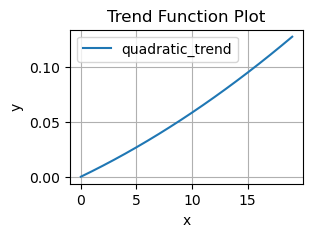

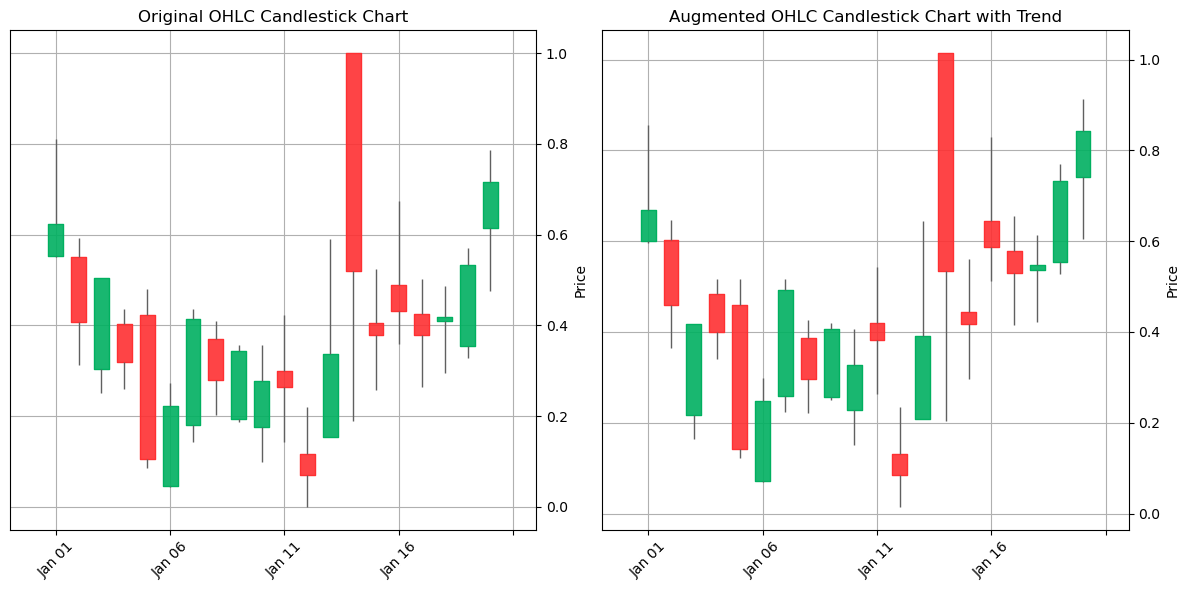

slope: 0.002755866089540568

Selected Chart Pattern: Head-and-shoulders top

Selected Trend Function: linear_trend


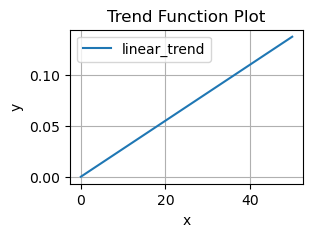

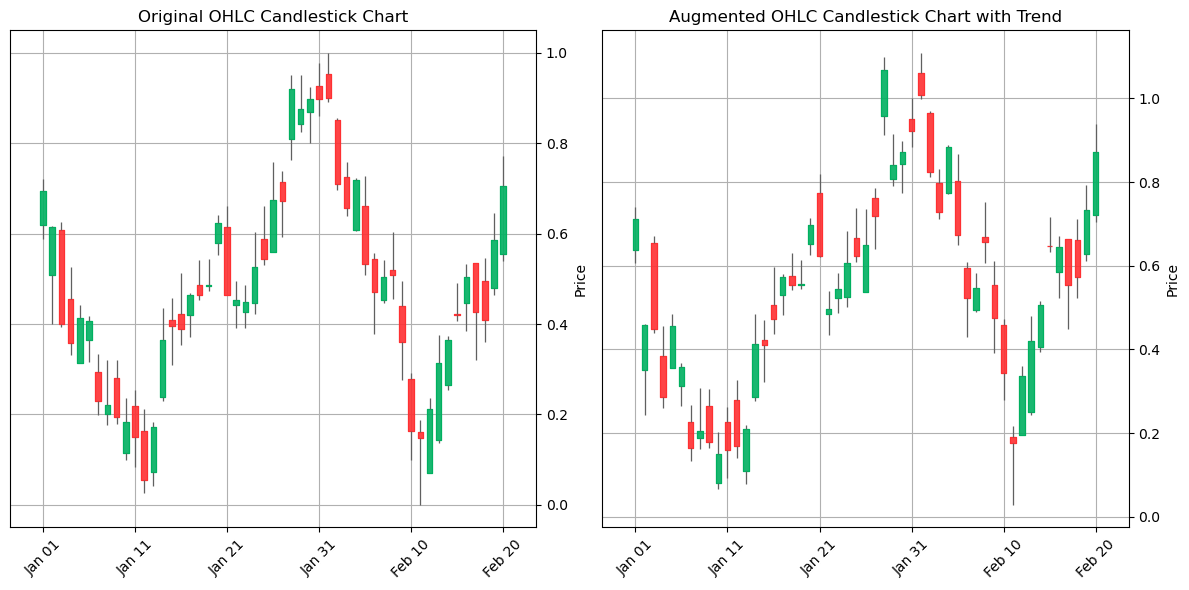

a: 3.5234631085717845e-05 b: 0.003613997764933032

Selected Chart Pattern: Triangle, symmetrical

Selected Trend Function: quadratic_trend


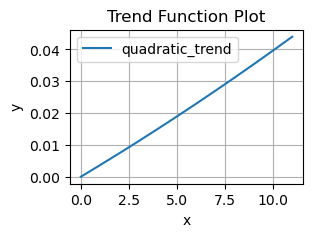

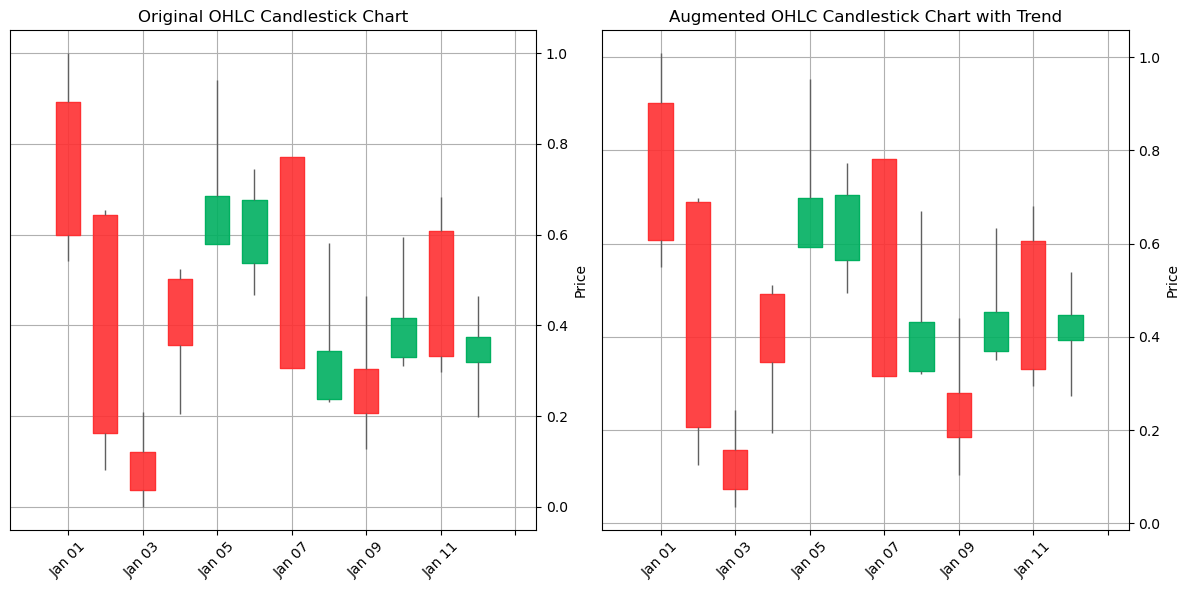

slope: 0.01122269458777247

Selected Chart Pattern: Triangle, symmetrical

Selected Trend Function: linear_trend


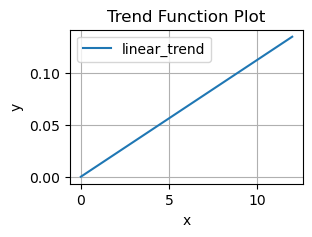

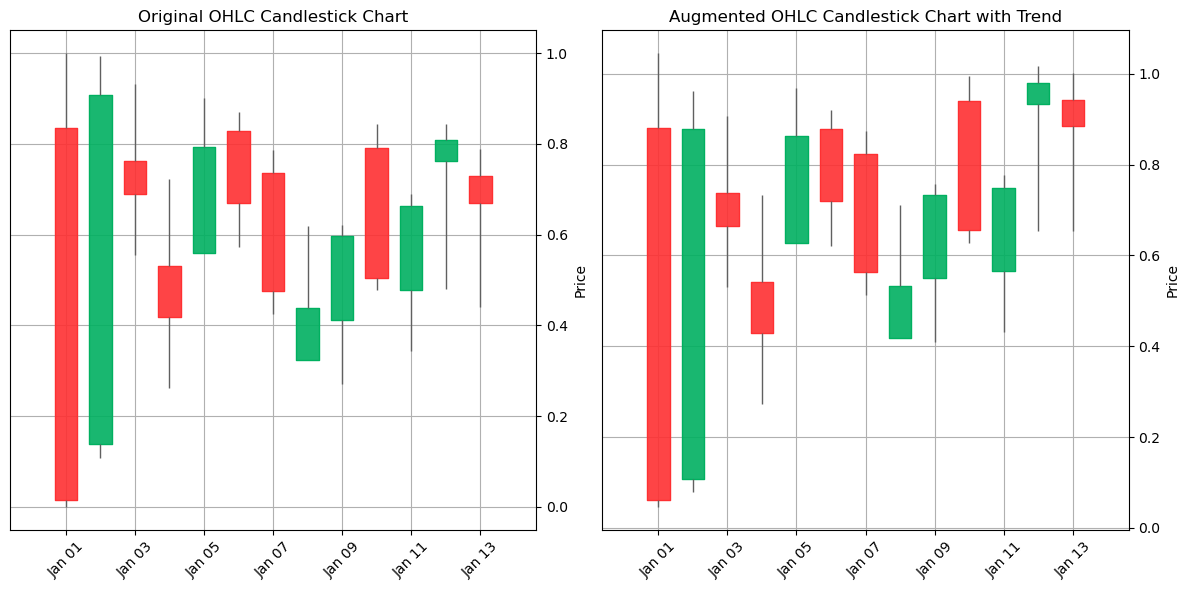

slope: 0.0052407918980169645

Selected Chart Pattern: Flag, high and tight

Selected Trend Function: linear_trend


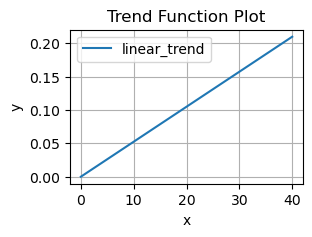

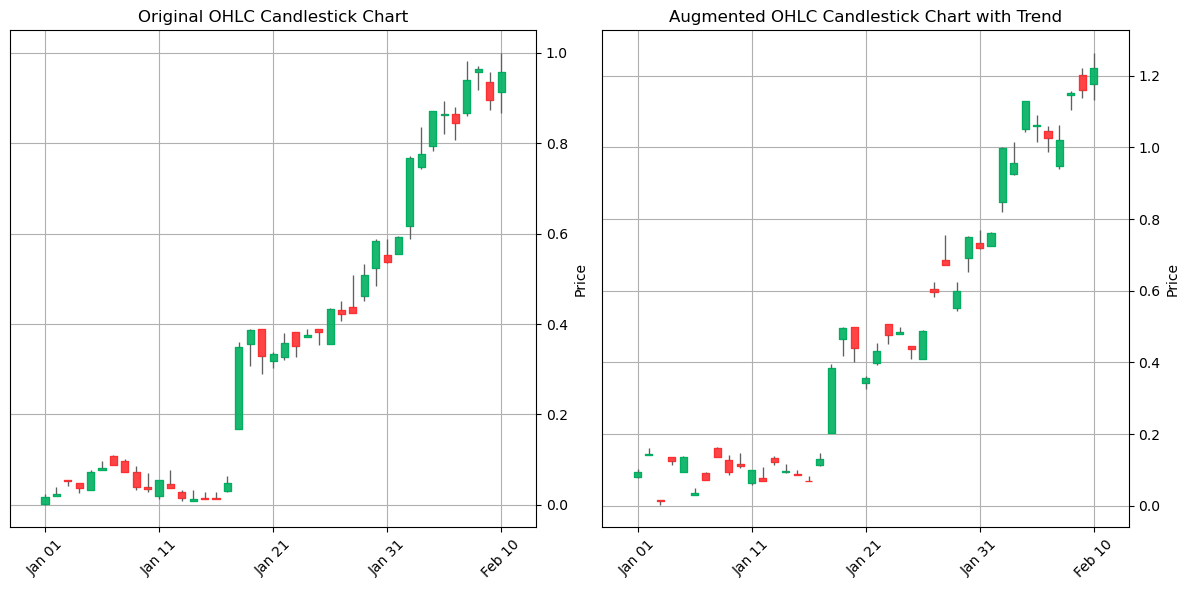

amplitude: 0.15762742773008198 frequency: 0.2803199490145034

Selected Chart Pattern: Flag, high and tight

Selected Trend Function: sine_trend


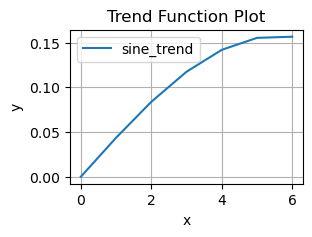

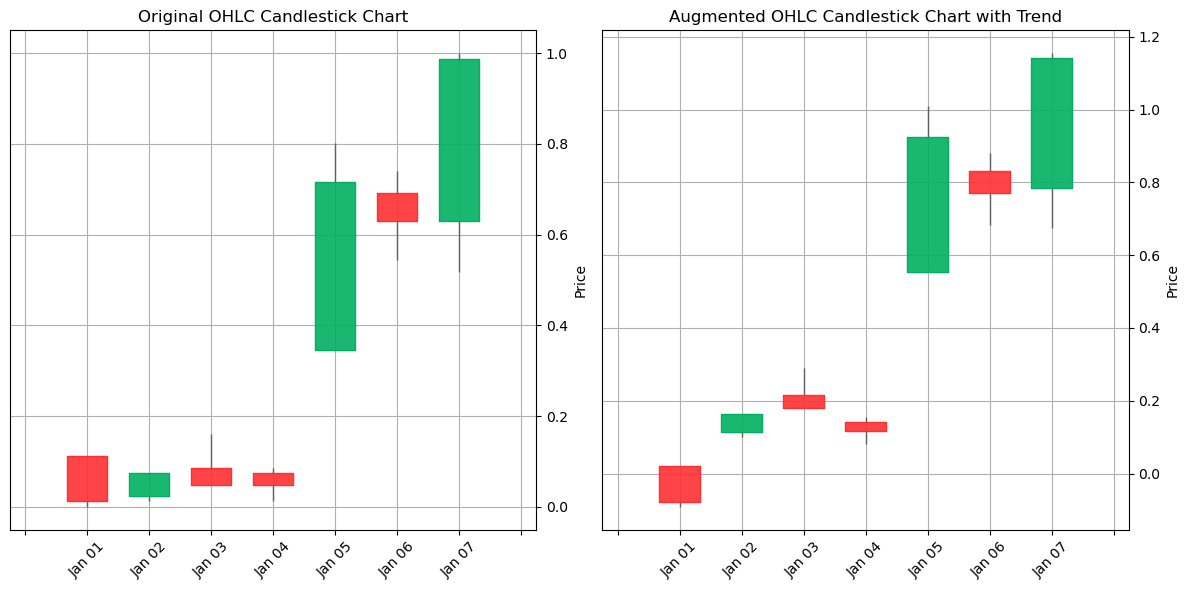

amplitude: 0.16982124325523992 frequency: 0.13840590466998584

Selected Chart Pattern: Head-and-shoulders bottom

Selected Trend Function: sine_trend


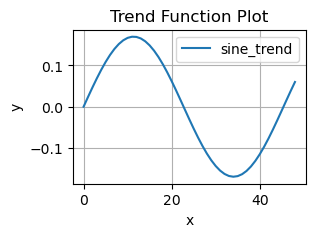

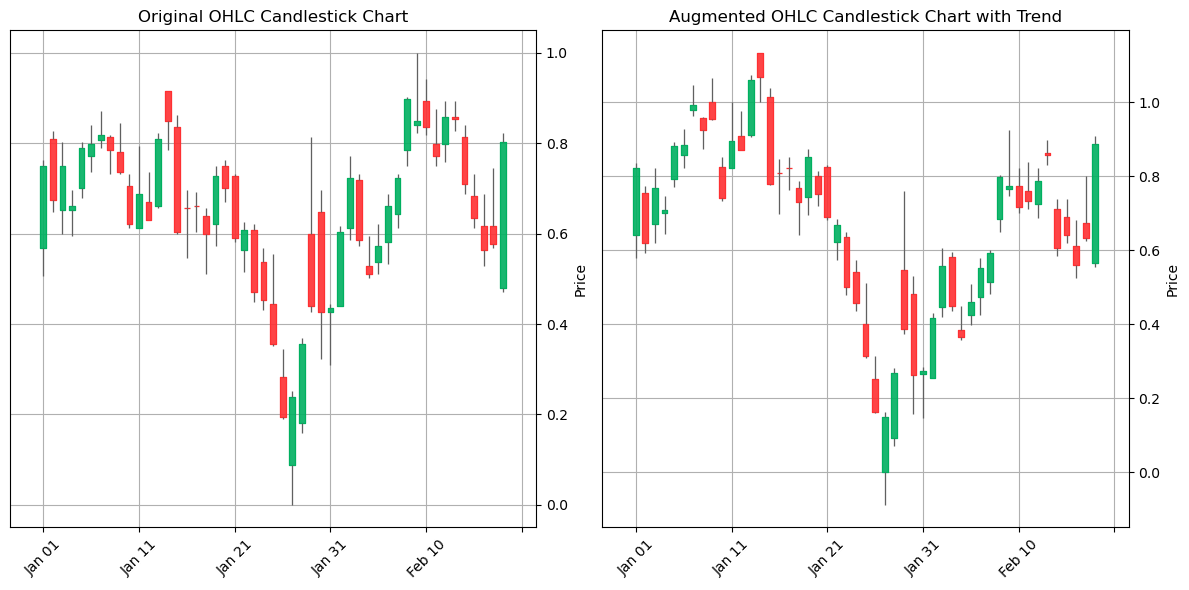

amplitude: 0.0448742275120808 frequency: 0.13411102818985363

Selected Chart Pattern: Head-and-shoulders bottom

Selected Trend Function: sine_trend


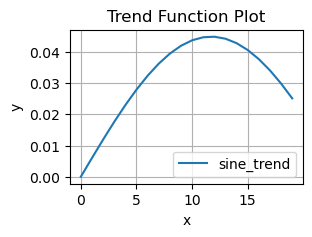

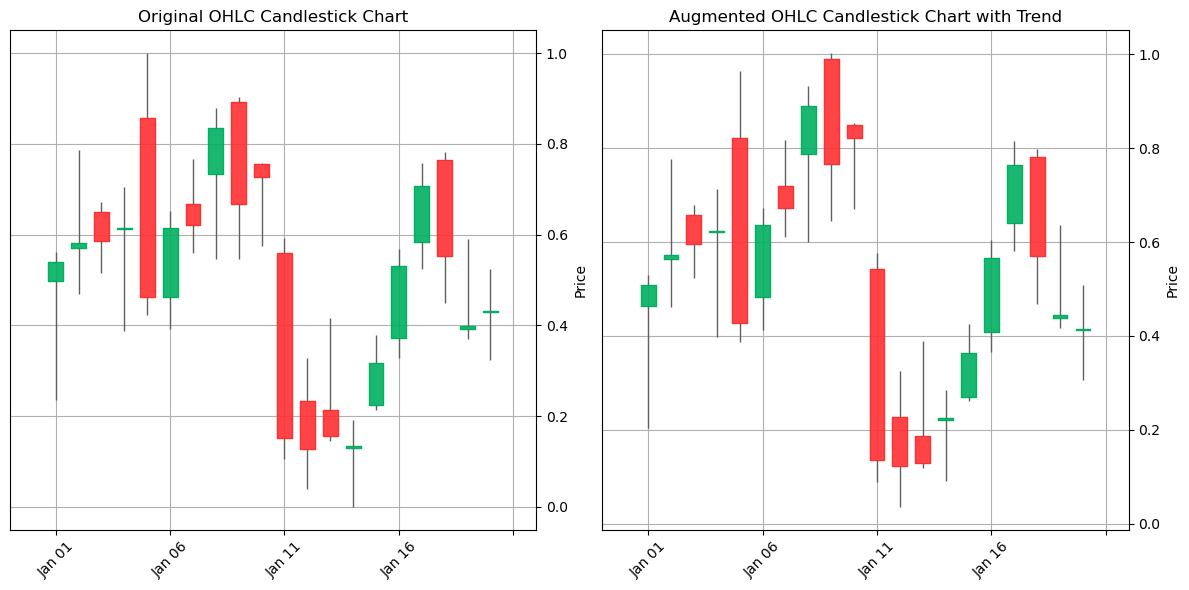

slope: 0.009100886826508146

Selected Chart Pattern: Triangle, symmetrical

Selected Trend Function: linear_trend


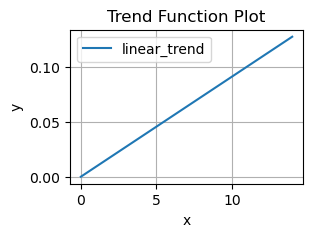

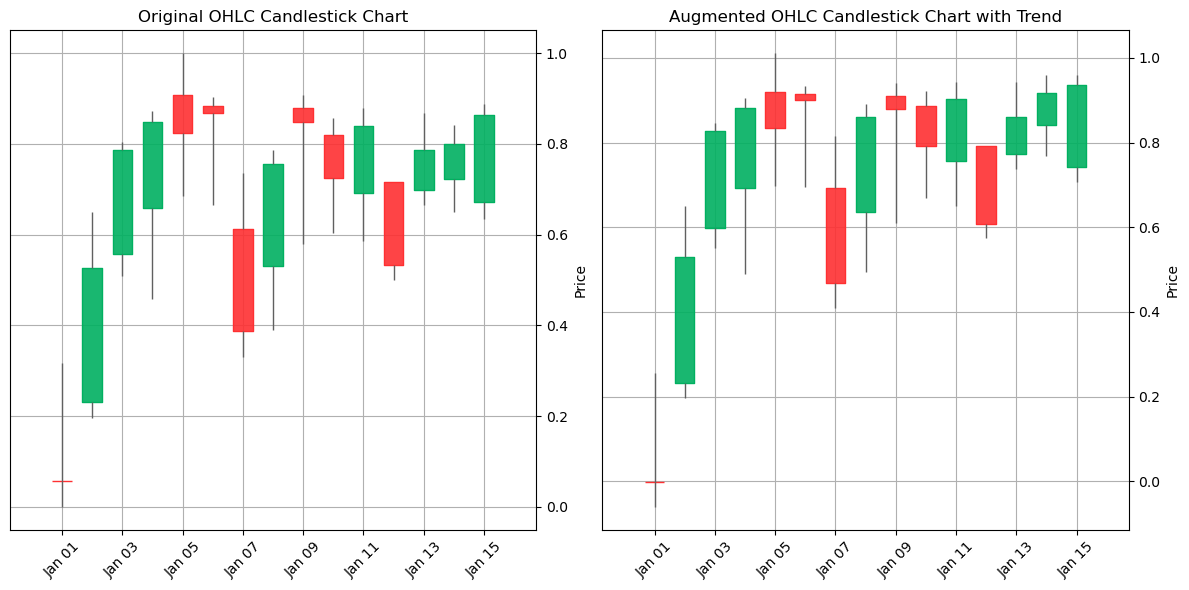

a: 3.0382566672447923e-05 b: 0.005097305093751923

Selected Chart Pattern: Head-and-shoulders top

Selected Trend Function: quadratic_trend


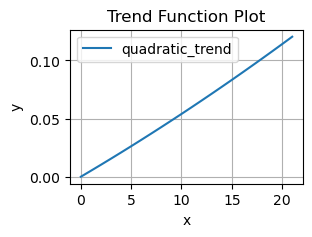

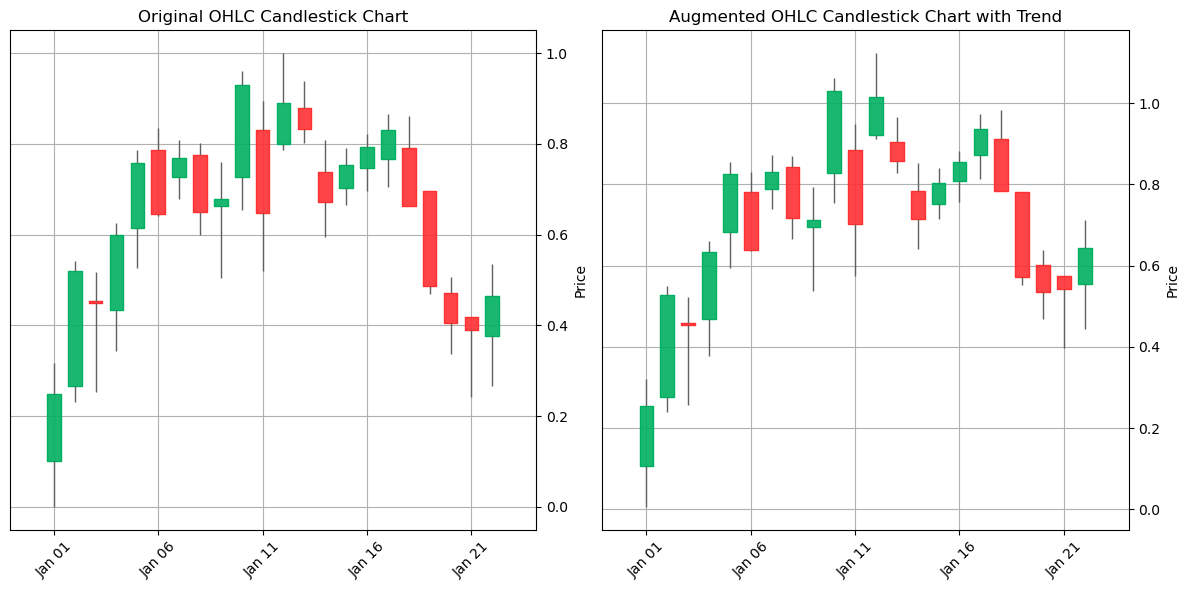

a: 3.717625422289482e-05 b: 0.005731364038232119

Selected Chart Pattern: Head-and-shoulders top

Selected Trend Function: quadratic_trend


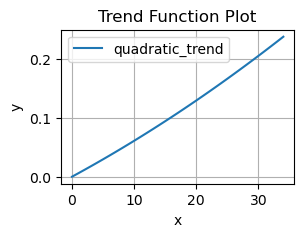

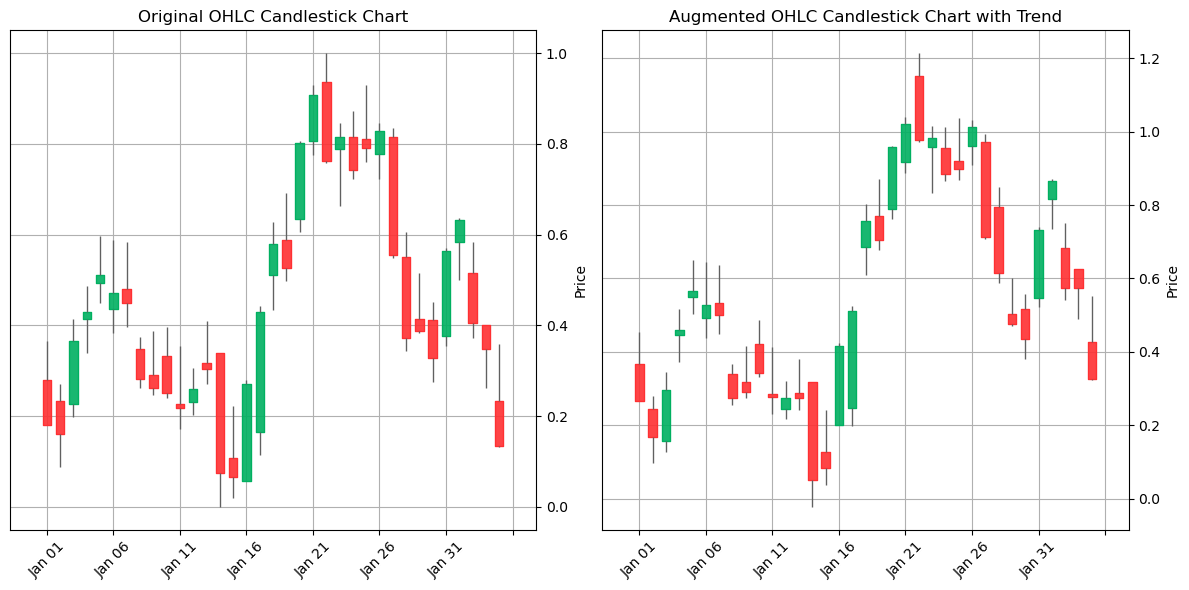

amplitude: 0.11561521124289473 frequency: 0.33764676146610695

Selected Chart Pattern: Head-and-shoulders bottom

Selected Trend Function: sine_trend


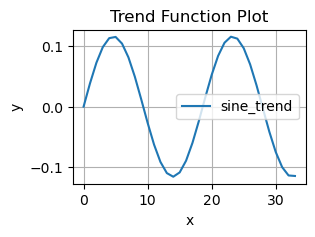

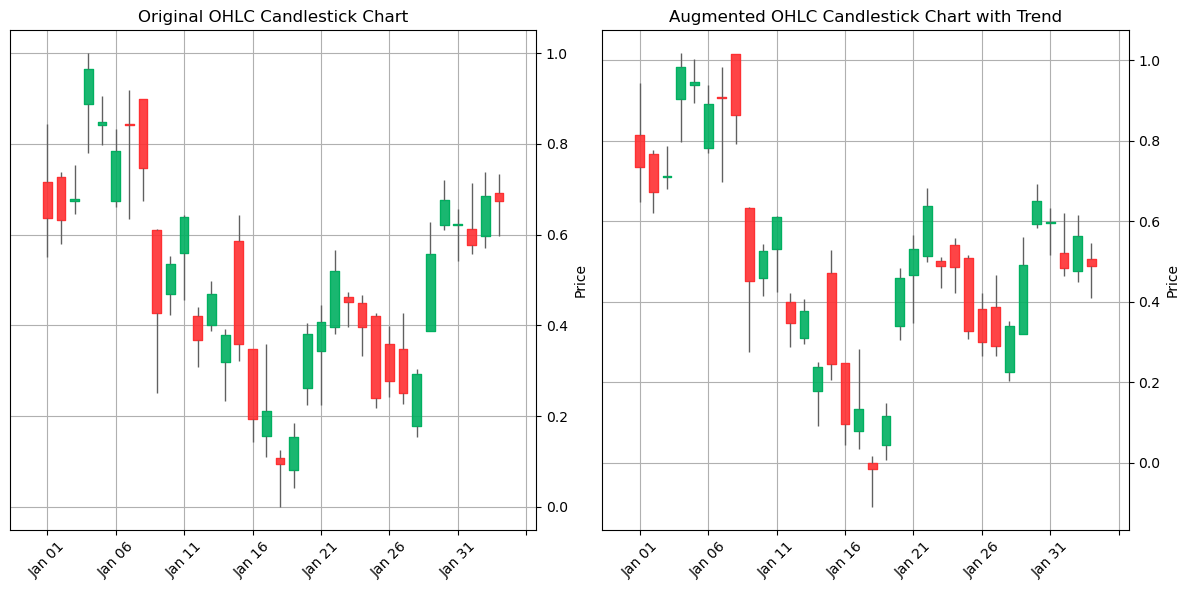

slope: 0.006976556096494951

Selected Chart Pattern: Head-and-shoulders bottom

Selected Trend Function: linear_trend


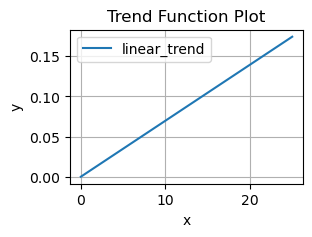

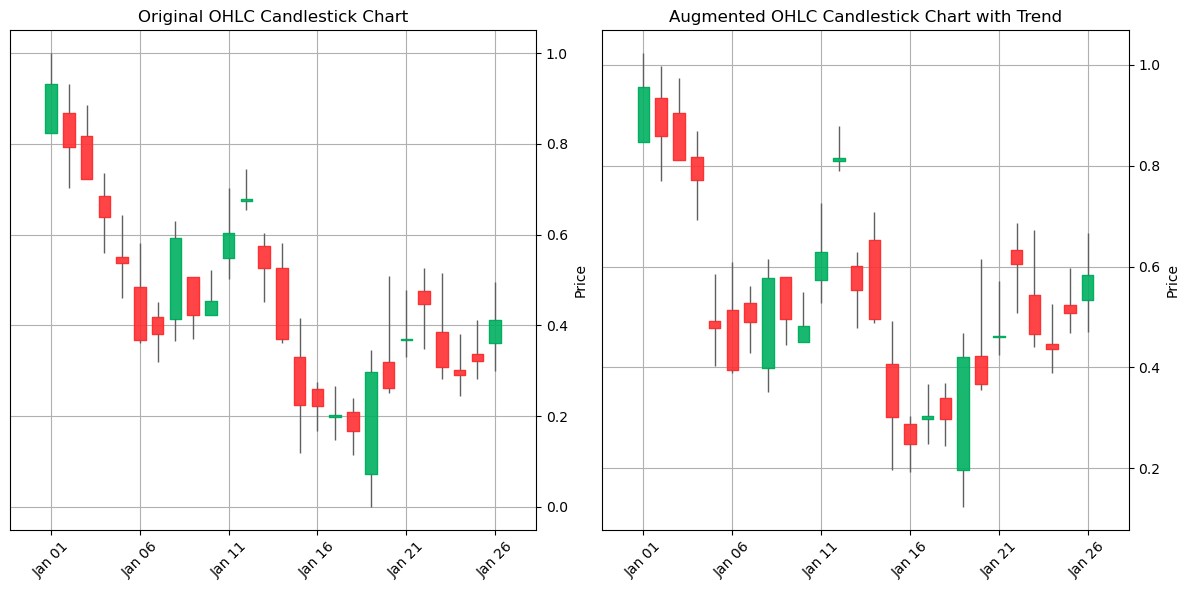

a: 9.744320560604371e-05 b: 0.004238471869169144

Selected Chart Pattern: Flag, high and tight

Selected Trend Function: quadratic_trend


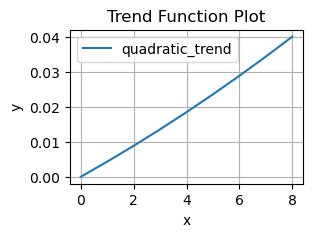

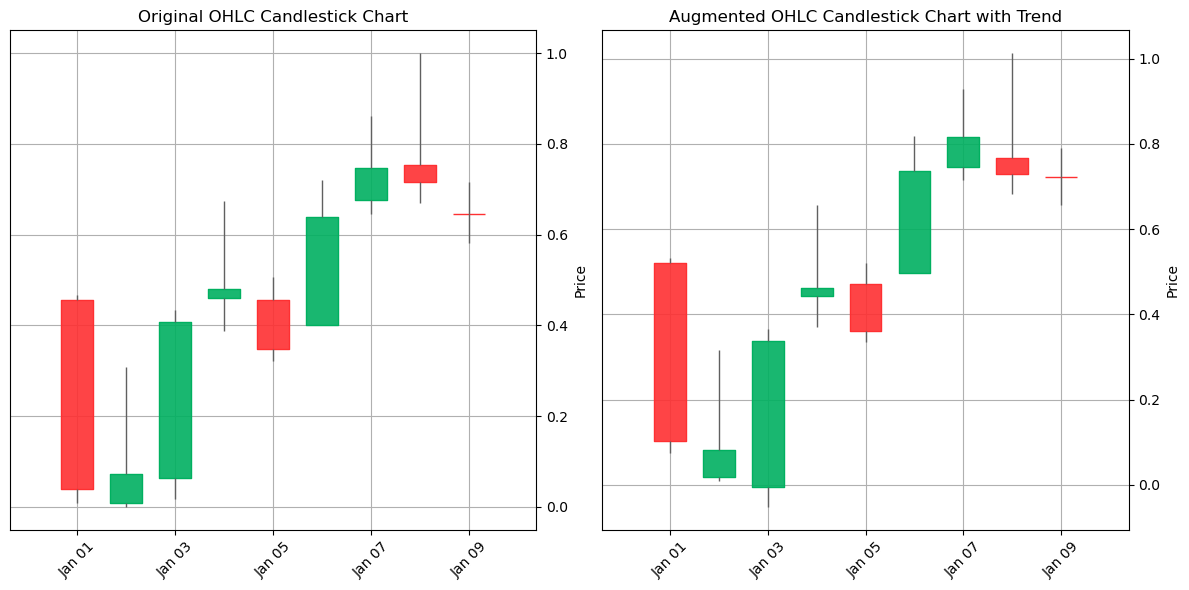

slope: 0.005149339835281828

Selected Chart Pattern: Flag, high and tight

Selected Trend Function: linear_trend


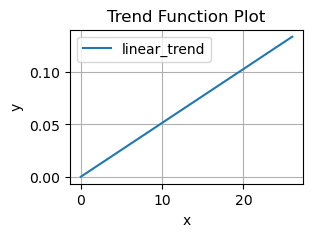

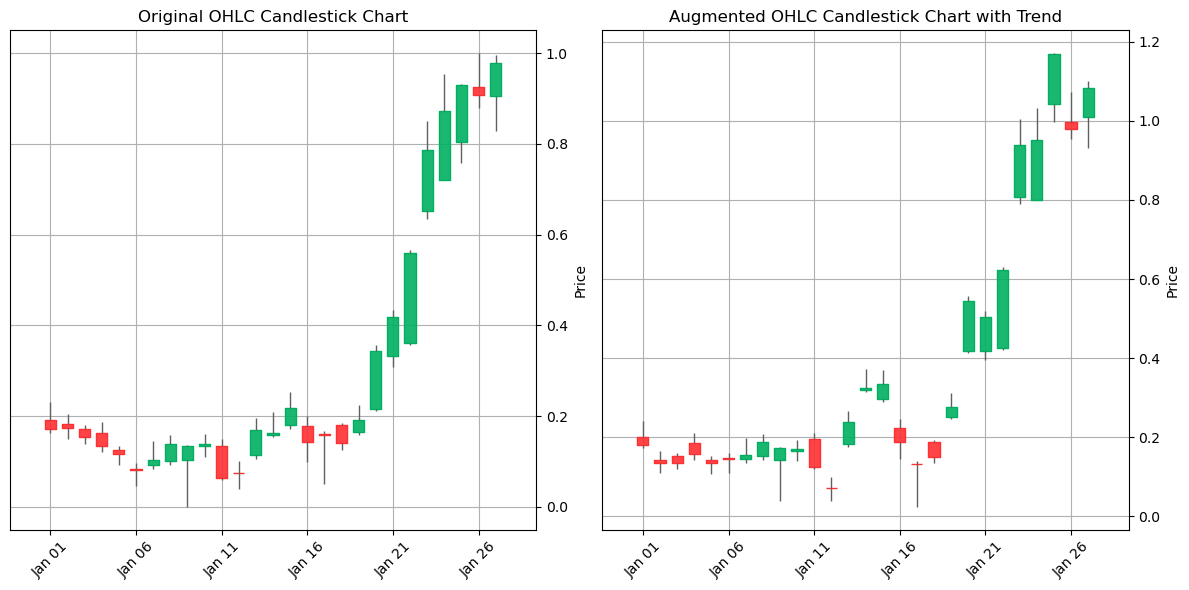

In [16]:
train_df_ohlc_aug = traindata_augment(train_df_ohlc)

train_df_w_aug_ohlc_aug = traindata_augment(train_df_w_aug_ohlc)

In [17]:
# get the number of unique instences of level 0 index and Pattern combinations
for pattern in train_df_ohlc_aug['Pattern'].unique():
    # Filter the Dataset for the current pattern
    pattern_data = train_df_ohlc_aug[train_df_ohlc_aug['Pattern'] == pattern]

    # Get the unique values from the first level of the multi-index
    unique_first_level_index = pattern_data.index.get_level_values(0).unique()
    print(f"Pattern: {get_patetrn_name_by_encoding(pattern)} - Unique Instances: {len(unique_first_level_index)}")

Pattern: No Pattern - Unique Instances: 1000
Pattern: Head-and-shoulders top - Unique Instances: 1000
Pattern: Double Bottom - Unique Instances: 1201
Pattern: Double Top - Unique Instances: 1134
Pattern: Triangle, symmetrical - Unique Instances: 1000
Pattern: Flag, high and tight - Unique Instances: 1000
Pattern: Head-and-shoulders bottom - Unique Instances: 1000


### TrainAugSwitch


In [18]:
train_df_ohlc_un_aug = train_df_ohlc.copy()
train_df_ohlc = train_df_ohlc_aug
# train_df_ohlc = train_df_ohlc_un_aug

## Length Normalize


In [40]:
from utils.drawPlots import plot_ohlc_segment
from utils.formatAndPreprocessNewPatterns import normalize_ohlc_len

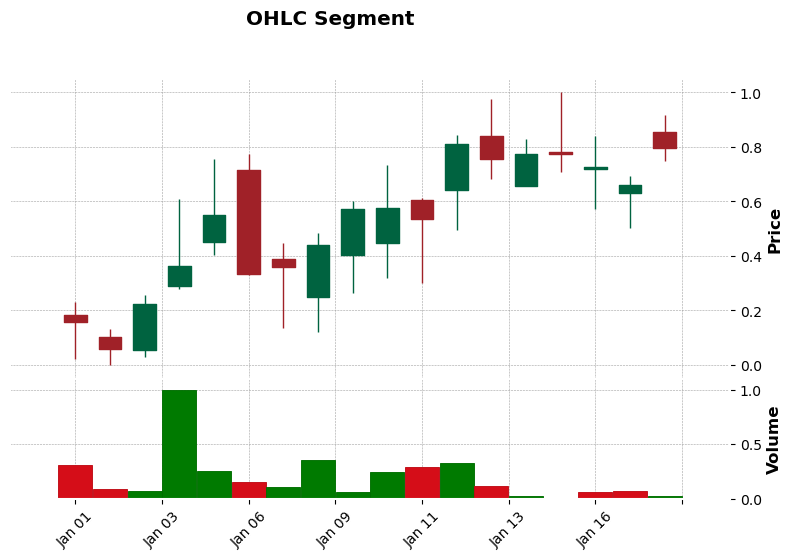

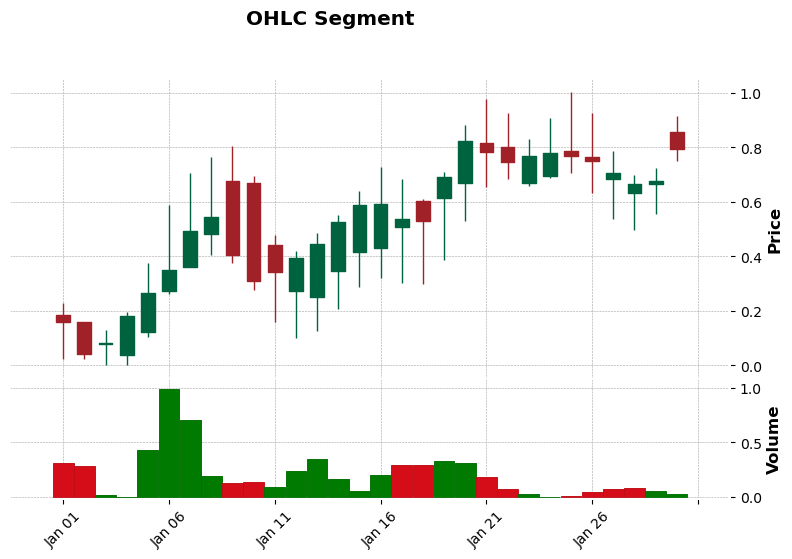

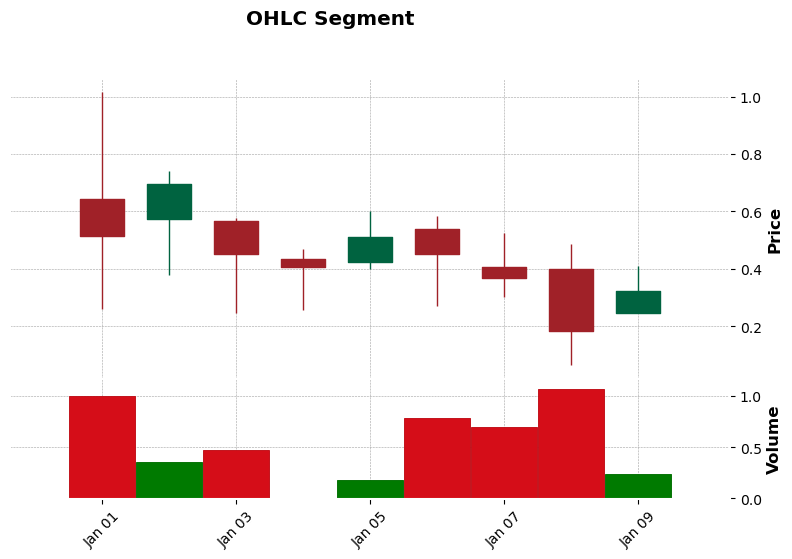

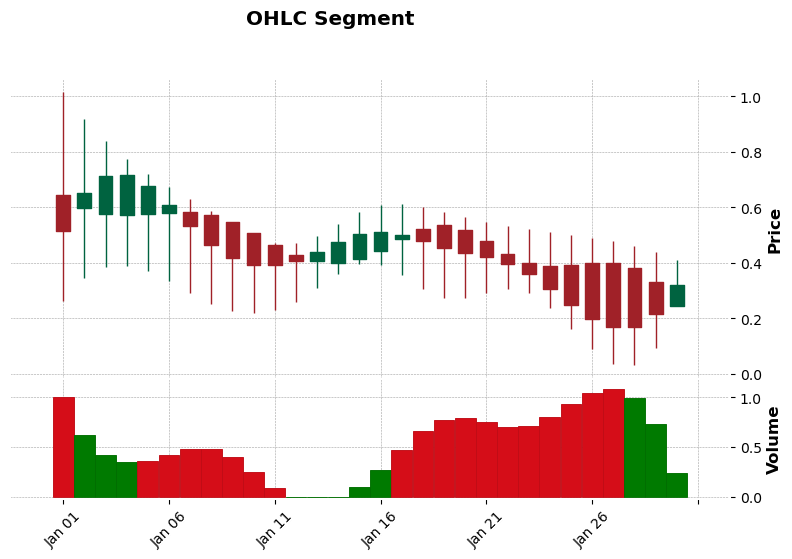

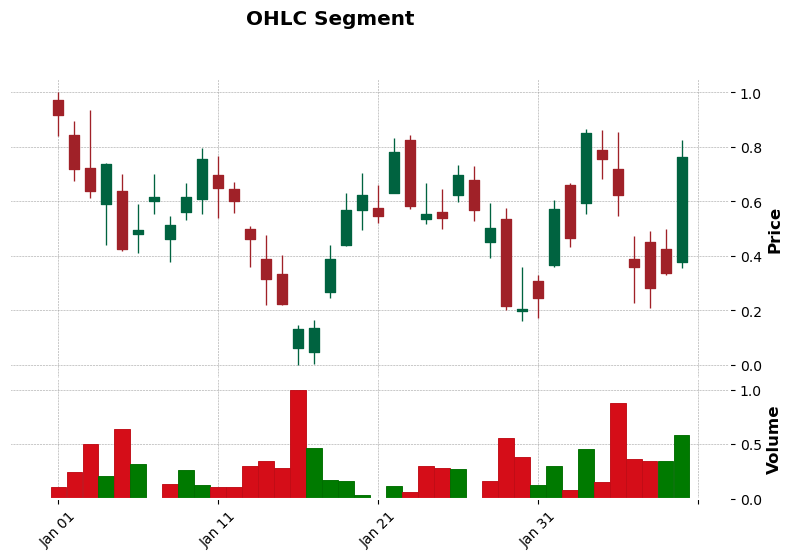

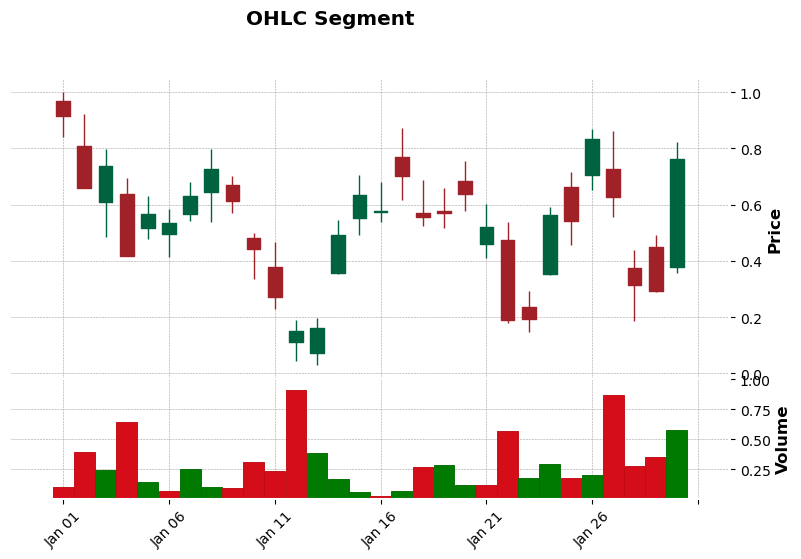

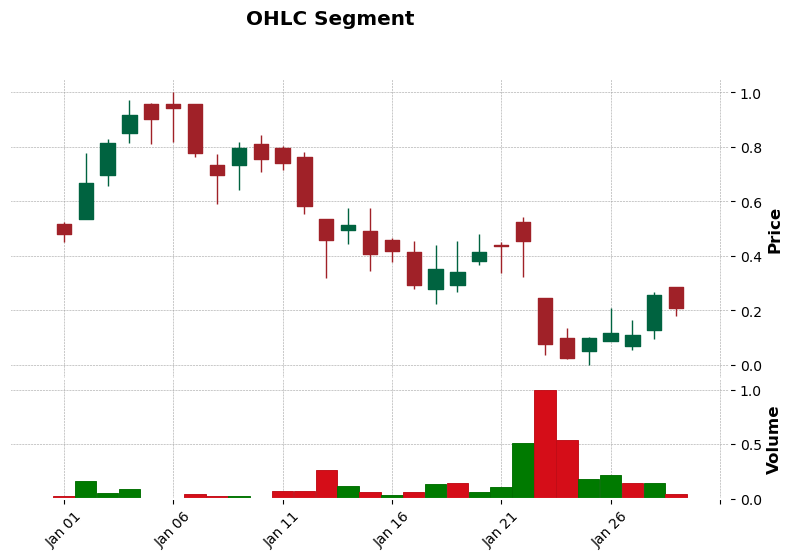

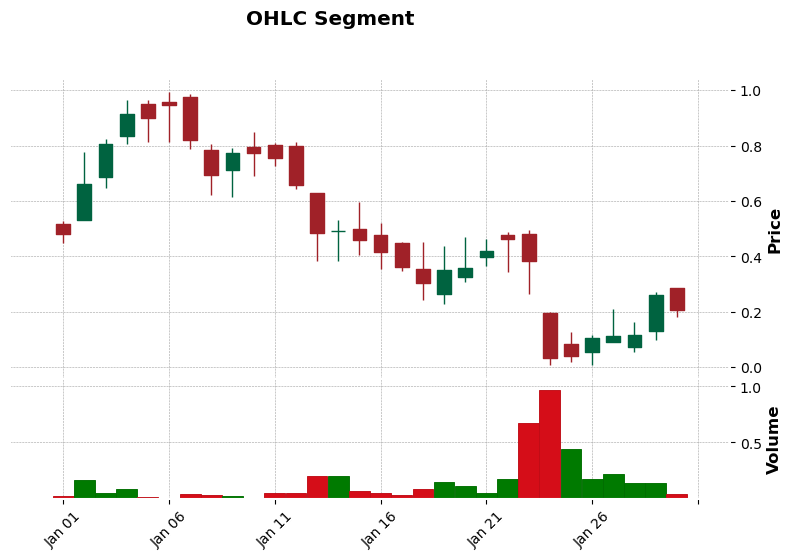

In [25]:
target_len =30
train_df_ohlc_len_normed = normalize_ohlc_len(train_df_ohlc, target_len=target_len,plot_count=2)
test_df_ohlc_len_normed = normalize_ohlc_len(test_df_ohlc, target_len=target_len,plot_count=2)

## Data set type dict


In [26]:
Datasets={}
Datasets["Plane OHLC"] = [train_df_ohlc, test_df_ohlc]
Datasets["Plane OHLC + traindata Aug"] = [train_df_ohlc_aug, test_df_ohlc]
Datasets["Width Aug OHLC"] = [train_df_w_aug_ohlc, test_df_w_aug_ohlc]
Datasets["Width Aug OHLC + traindata Aug"] = [train_df_w_aug_ohlc_aug , test_df_w_aug_ohlc]
Datasets["Length Normed OHLC"] = [train_df_ohlc_len_normed, test_df_ohlc_len_normed]

# Classification


In [27]:
model_stats = {}
models = {}

## Usual Classifier


In [28]:
# Define features and target
features = ['Open', 'High', 'Low', 'Close', 'Volume']
target = 'Pattern'
series_length = 100  # Target series length for ROCKET

def adjust_series_length(group, target_length):

    series = group.values
    current_length = len(series)

    if current_length > target_length:
        return series[:target_length]
    else:
        # Padding with zeros if shorter
        padding = np.zeros((target_length - current_length, series.shape[1]))
        return np.vstack([series, padding])


def prepare_rocket_data(dataset, features, target, series_length):
    # Group by 'Instance' and adjust each series length
    adjusted = dataset.groupby(level=0).apply(
        lambda group: adjust_series_length(group[features], series_length)
    )
    
    # Stack adjusted arrays
    X = np.stack(adjusted.values)  # Shape: (num_samples, series_length, num_features)

    # Extract targets (one per instance)
    y = dataset.groupby(level=0)[target].first().values  # Shape: (num_samples,)
    
    X = np.transpose(X, (0, 2, 1)) # shape: (num_samples, num_features, series_length)

    return X, y

# Prepare training and testing data
X_train, y_train = prepare_rocket_data(train_df_ohlc, features, target, series_length)
X_test, y_test = prepare_rocket_data(test_df_ohlc, features, target, series_length)

print(f"X_train shape: {X_train.shape}")  # Expect (7080, 5, 100)
print(f"y_train shape: {y_train.shape}")  # Expect (7080,)

X_train shape: (7335, 5, 100)
y_train shape: (7335,)


### Rocket Classifier


In [29]:
from sktime.transformations.panel.rocket import Rocket
from sklearn.pipeline import make_pipeline
# from utils.FixedLengthTransformer import FixedLengthTransformer
import time
from xgboost import XGBClassifier


# fl = FixedLengthTransformer(fixed_length=100, fill_value=0)
rocket = Rocket(num_kernels=10000)
xgbr = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss', 
    n_estimators=100,
    device="cuda"
)

clf_xgb = make_pipeline(
    # fl,
    rocket,
    xgbr
)

models['rocket_xgb'] = clf_xgb



### Mini Rocket Classifier


In [33]:
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.pipeline import make_pipeline
# from utils.FixedLengthTransformer import FixedLengthTransformer
import time
from xgboost import XGBClassifier


# fl = FixedLengthTransformer(fixed_length=100, fill_value=0)
mini_rocket = MiniRocketMultivariate(num_kernels=5000)
xgb_mr = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss', 
    n_estimators=100,
    device="cuda"
)

clf_xgb_mr = make_pipeline(
    # fl,
    mini_rocket,
    xgb_mr
)


models['mini_rocket_xgb'] = clf_xgb_mr



### Multi Rocket Classifier


In [37]:
from sktime.transformations.panel.rocket import MultiRocketMultivariate
from sklearn.pipeline import make_pipeline
# from utils.FixedLengthTransformer import FixedLengthTransformer
import time
from xgboost import XGBClassifier


# fl = FixedLengthTransformer(fixed_length=100, fill_value=0)
multi_rocket = MultiRocketMultivariate(num_kernels=5000)
xgb_mur = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss', 
    n_estimators=100,
    device="cuda"
)


clf_xgb_mur = make_pipeline(
    # fl,
    multi_rocket,
    xgb_mur
)


models['multi_rocket_xgb'] = clf_xgb_mur



## Train - Test - Evaluate


Training Plane OHLC rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:13:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('rocket', Rocket()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:23:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Status for {key_data} {key} : /n {'Plane OHLC rocket_xgb_train_time': 597.9720447063446, 'Plane OHLC rocket_xgb_test_time': 33.216251373291016, 'Plane OHLC rocket_xgb_test_accuracy': 0.8668555240793201, 'Plane OHLC rocket_xgb_train_accuracy': 1.0}


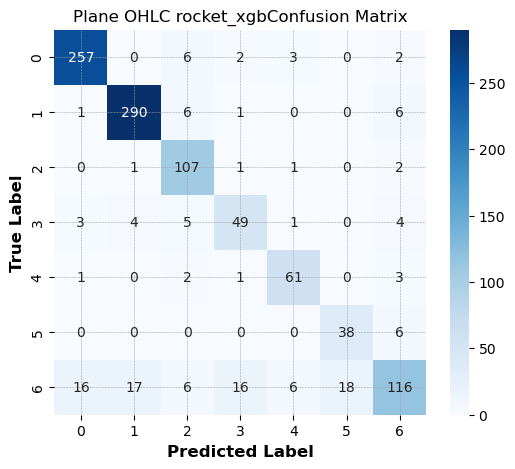

Training Plane OHLC + traindata Aug rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:27:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('rocket', Rocket()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

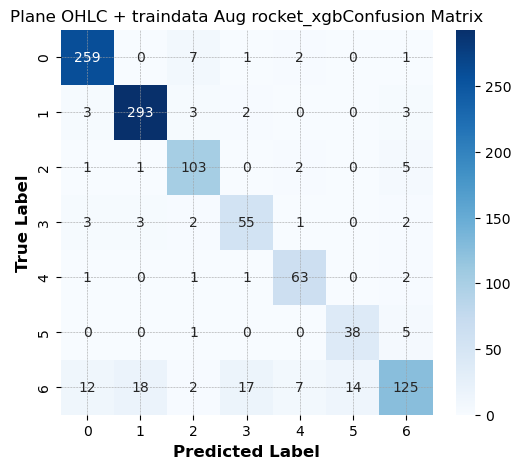

Training Width Aug OHLC rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:40:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('rocket', Rocket()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

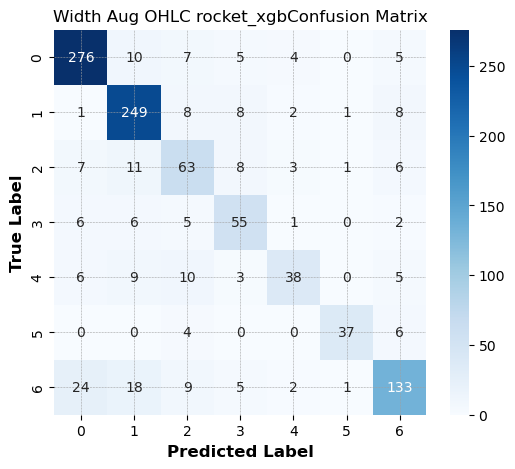

Training Width Aug OHLC + traindata Aug rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:52:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('rocket', Rocket()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

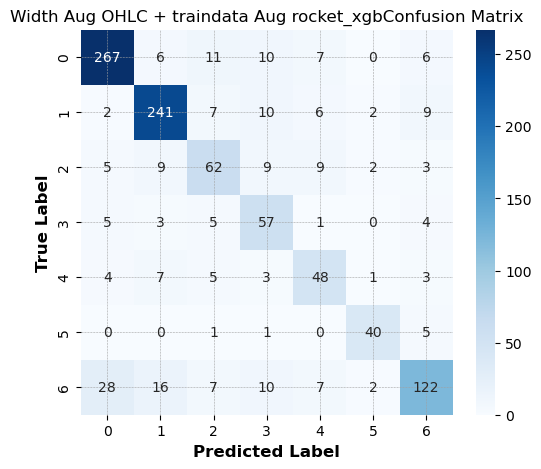

Training Length Normed OHLC rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:08:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('rocket', Rocket()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

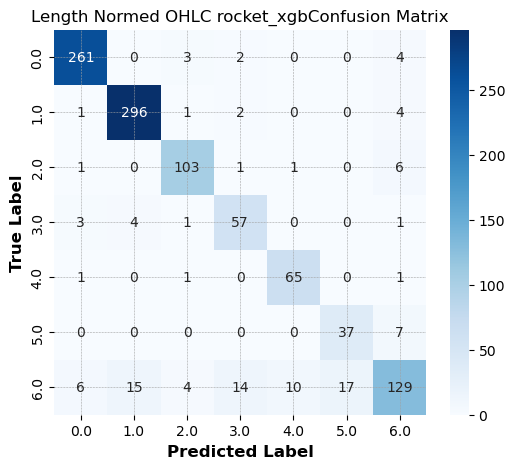

Training Plane OHLC mini_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:17:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('minirocketmultivariate',
                 MiniRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

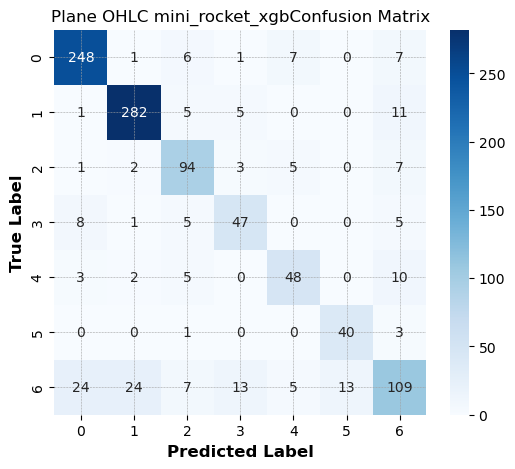

Training Plane OHLC + traindata Aug mini_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:18:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('minirocketmultivariate',
                 MiniRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

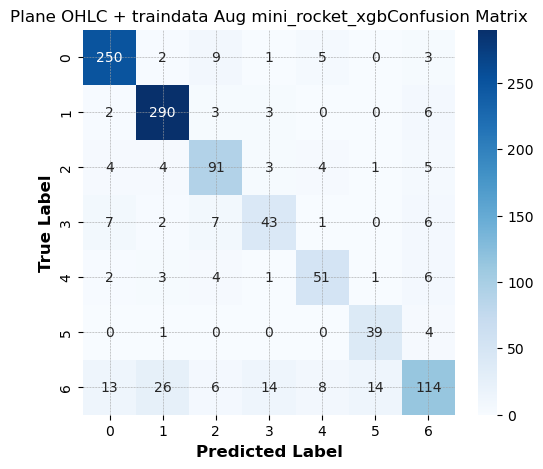

Training Width Aug OHLC mini_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:19:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('minirocketmultivariate',
                 MiniRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

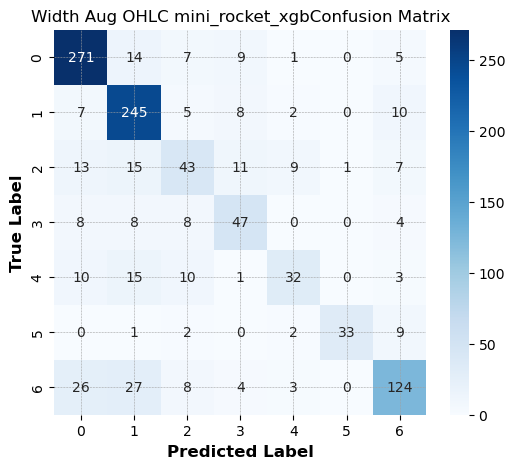

Training Width Aug OHLC + traindata Aug mini_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:20:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('minirocketmultivariate',
                 MiniRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

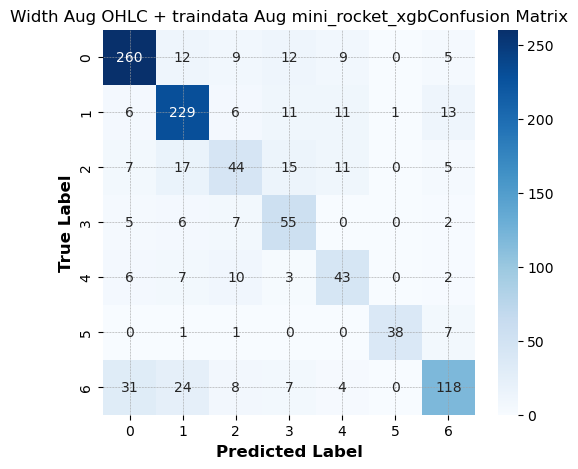

Training Length Normed OHLC mini_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:21:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('minirocketmultivariate',
                 MiniRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, grow_...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

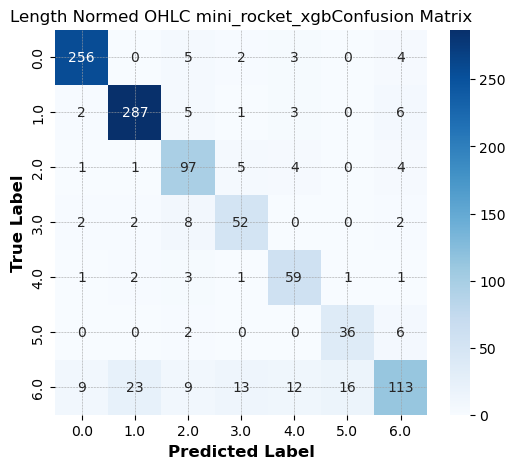

Training Plane OHLC multi_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:23:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('multirocketmultivariate',
                 MultiRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, gro...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

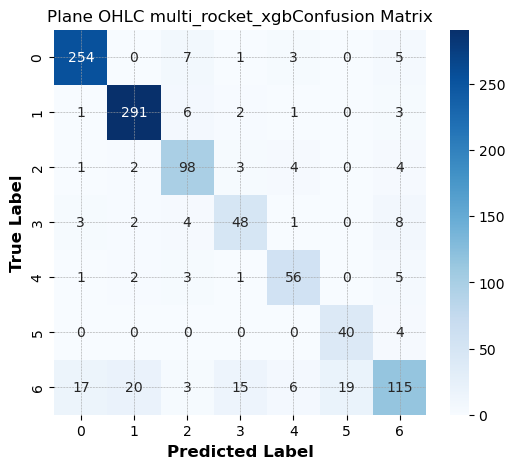

Training Plane OHLC + traindata Aug multi_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:56:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('multirocketmultivariate',
                 MultiRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, gro...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

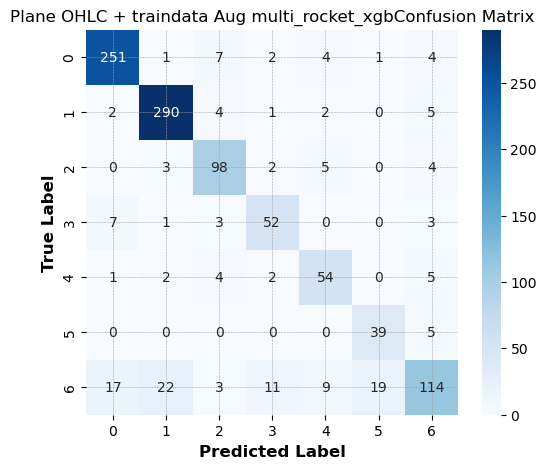

Training Width Aug OHLC multi_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:58:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('multirocketmultivariate',
                 MultiRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, gro...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

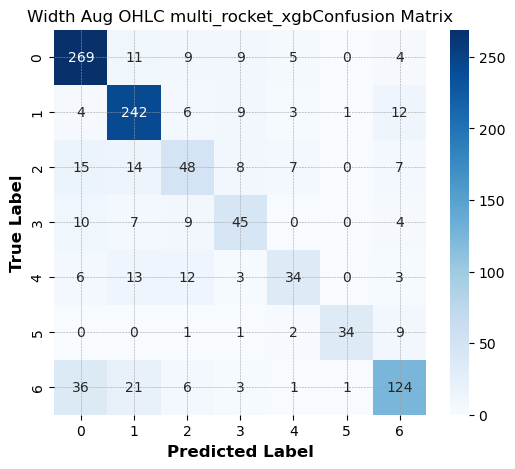

Training Width Aug OHLC + traindata Aug multi_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:04:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('multirocketmultivariate',
                 MultiRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, gro...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

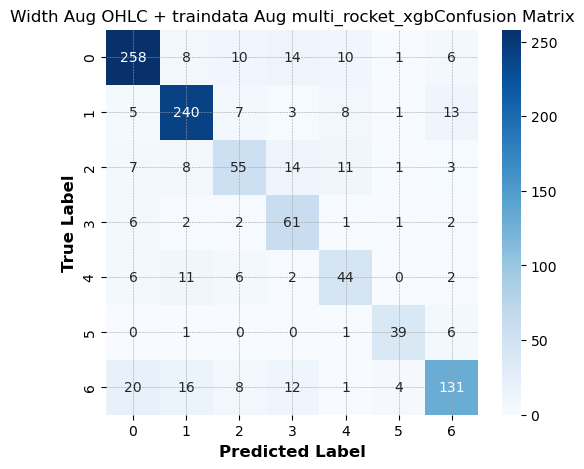

Training Length Normed OHLC multi_rocket_xgb ...


c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [04:34:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('multirocketmultivariate',
                 MultiRocketMultivariate(num_kernels=5000)),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, gamma=None, gro...None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
           

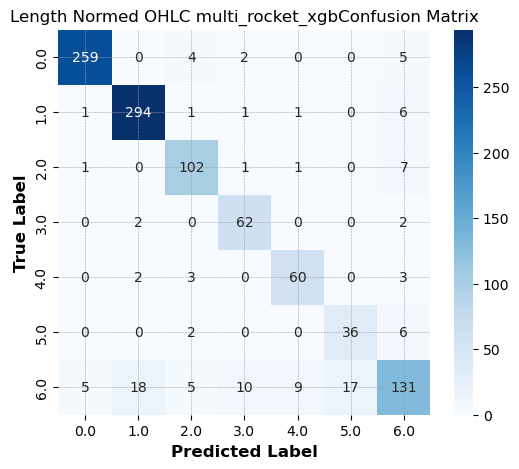

In [44]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib
import os

for key, value in models.items():
    clf_xgb = value
    model_stats_data = {}
    for key_data, value_data in Datasets.items():              
        X_train, y_train = prepare_rocket_data(value_data[0], features, target, series_length)
        X_test, y_test = prepare_rocket_data(value_data[1], features, target, series_length)
        
        
        # Train
        print(f"Training {key_data} {key} ...")
        
        train_start = time.time()
        clf_xgb.fit(X_train, y_train)
        train_end = time.time()
        train_time = train_end - train_start

        model_stats_data[f'{key_data} {key}_train_time'] = train_time

        print(clf_xgb)
        # save the model
        # Create the "Models" directory if it doesn't exist
        if not os.path.exists("Models"):
            os.makedirs("Models")
        joblib.dump(clf_xgb, f"Models/{key_data}_{key}.joblib")
        
        # Test
        print(f"Testing {key_data} {key} ...")
        
        y_train_probs = clf_xgb.predict_proba(X_train) 
        test_start = time.time()
        y_test_probs = clf_xgb.predict_proba(X_test)
        test_end = time.time()
        test_time = test_end - test_start
        model_stats_data[f'{key_data} {key}_test_time'] = test_time
        
        # Evaluate
        
        

        # Training accuracy
        y_train_pred = y_train_probs.argmax(axis=1)  
        train_accuracy = accuracy_score(y_train, y_train_pred)
        # print(f"Training Accuracy: {train_accuracy:.2f}")

        # Testing accuracy
        y_test_pred = y_test_probs.argmax(axis=1)  
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # print(f"Test Accuracy: {test_accuracy:.2f}")
        
        model_stats_data[f'{key_data} {key}_test_accuracy'] = test_accuracy
        model_stats_data[f'{key_data} {key}_train_accuracy'] = train_accuracy
        
        print("Status for {key_data} {key} : /n" , model_stats_data)
        # Confusion matrix
        conf_matrix = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test), yticklabels=set(y_test))
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"{key_data} {key}Confusion Matrix")
        plt.show()
    
    model_stats[key] = model_stats_data


In [45]:
model_stats

{'rocket_xgb': {'Plane OHLC rocket_xgb_train_time': 597.9720447063446,
  'Plane OHLC rocket_xgb_test_time': 33.216251373291016,
  'Plane OHLC rocket_xgb_test_accuracy': 0.8668555240793201,
  'Plane OHLC rocket_xgb_train_accuracy': 1.0,
  'Plane OHLC + traindata Aug rocket_xgb_train_time': 590.274168252945,
  'Plane OHLC + traindata Aug rocket_xgb_test_time': 33.41511535644531,
  'Plane OHLC + traindata Aug rocket_xgb_test_accuracy': 0.8838526912181303,
  'Plane OHLC + traindata Aug rocket_xgb_train_accuracy': 1.0,
  'Width Aug OHLC rocket_xgb_train_time': 473.3111207485199,
  'Width Aug OHLC rocket_xgb_test_time': 33.55227303504944,
  'Width Aug OHLC rocket_xgb_test_accuracy': 0.7968164794007491,
  'Width Aug OHLC rocket_xgb_train_accuracy': 1.0,
  'Width Aug OHLC + traindata Aug rocket_xgb_train_time': 723.6073951721191,
  'Width Aug OHLC + traindata Aug rocket_xgb_test_time': 33.716989517211914,
  'Width Aug OHLC + traindata Aug rocket_xgb_test_accuracy': 0.7837078651685393,
  'Width

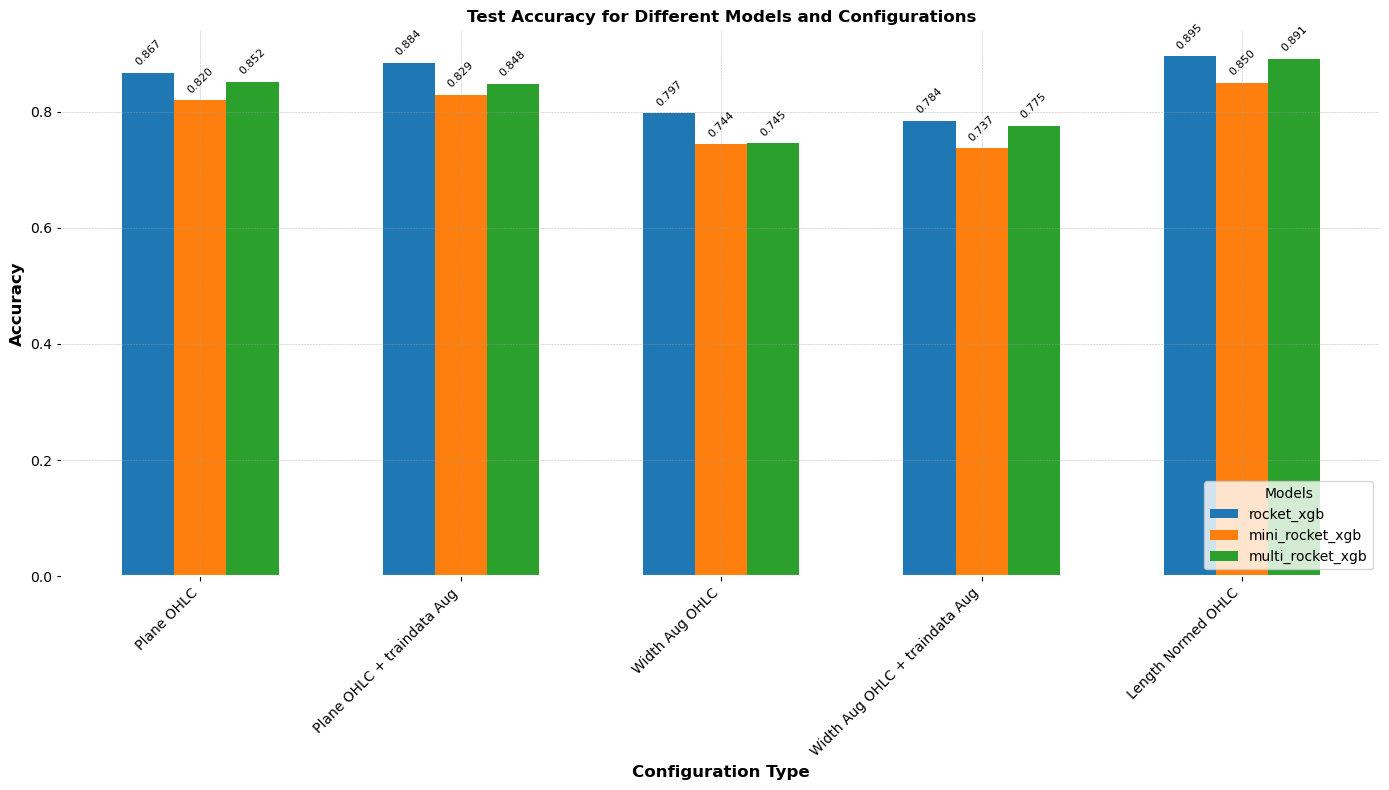

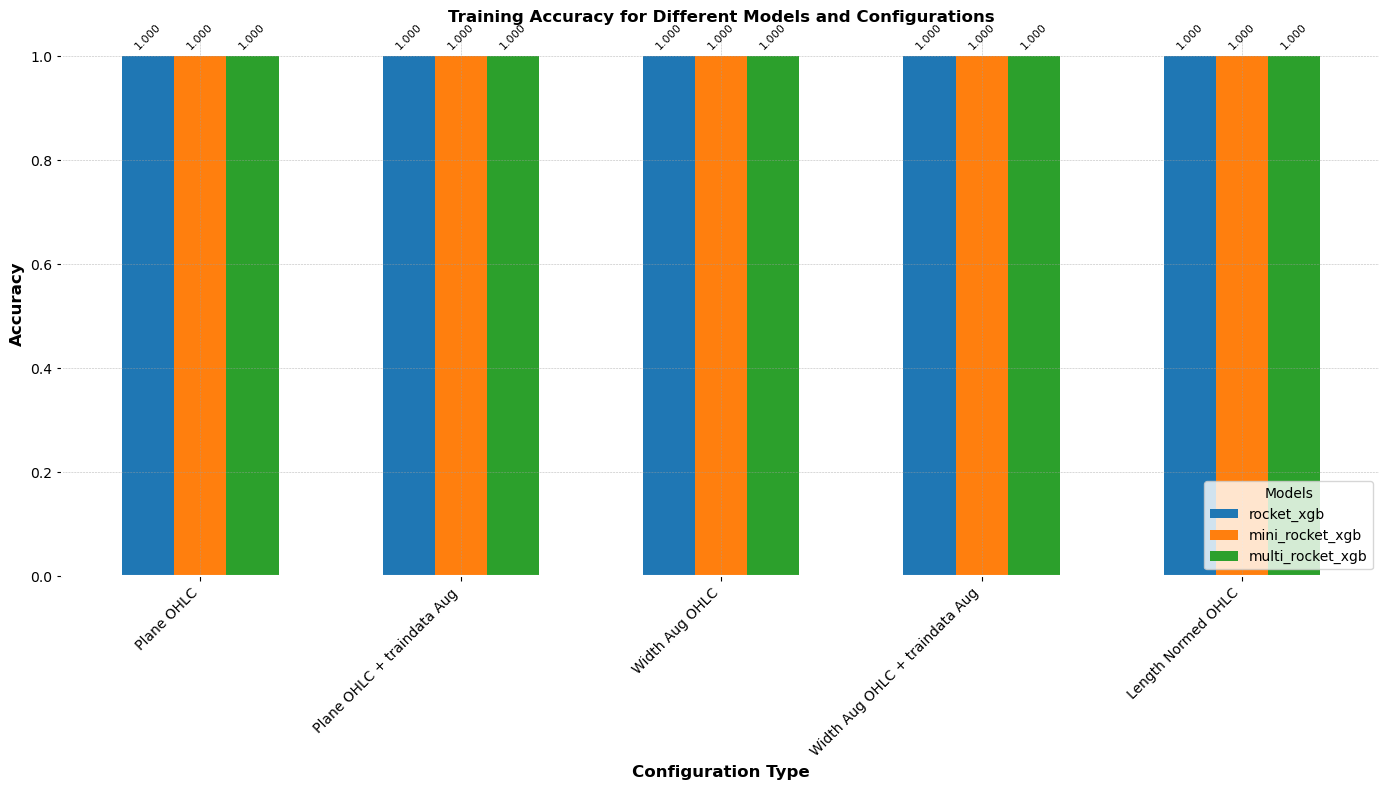

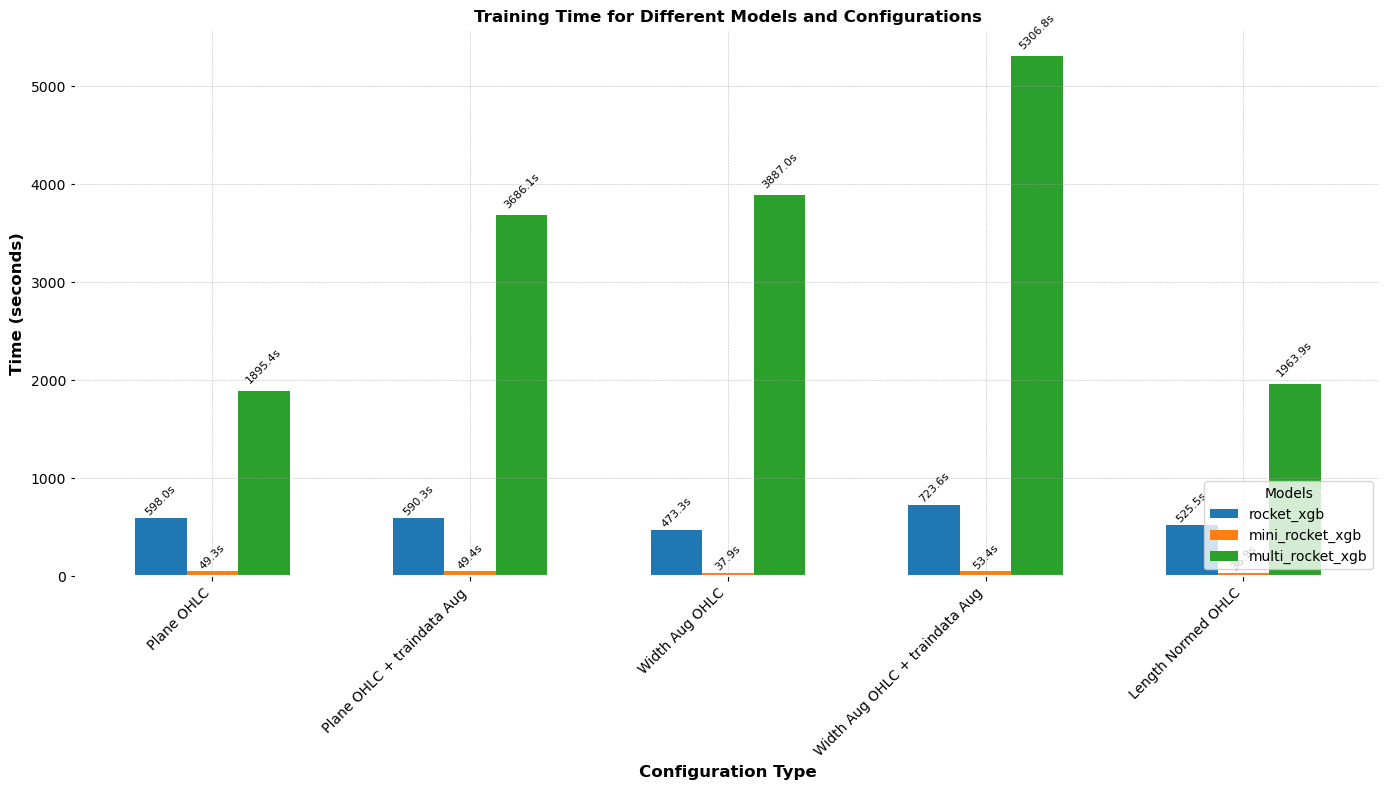

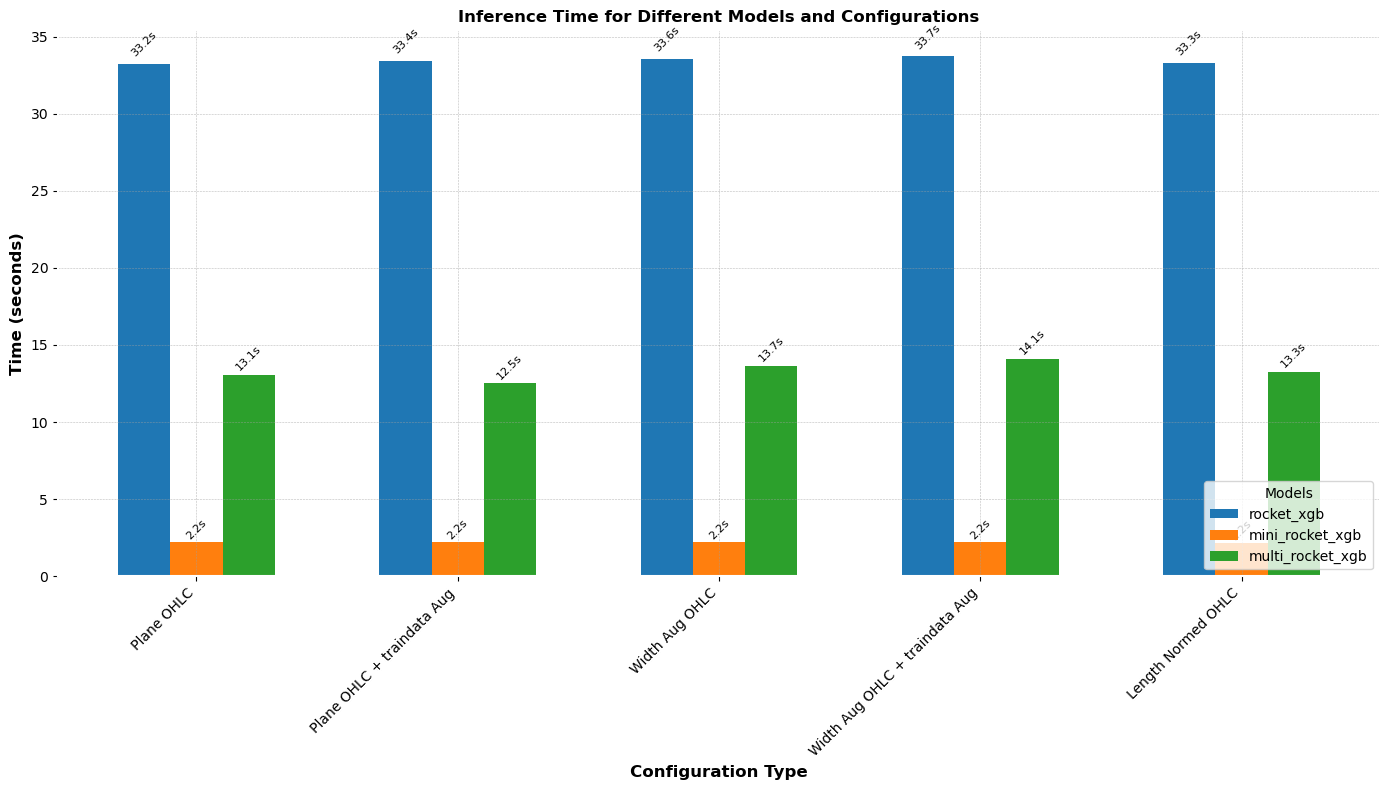

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert the nested dictionary to a more usable format
def extract_metrics(results_dict):
    data = []
    
    for model_name, configs in results_dict.items():
        for config_name, metrics in configs.items():
            # Extract the configuration type (before the model name)
            config_type = config_name.split(f"{model_name}_")[0].strip()
            
            # Extract specific metrics
            if 'test_accuracy' in config_name:
                metric_type = 'test_accuracy'
                data.append({
                    'model': model_name,
                    'config': config_type,
                    'metric': metric_type,
                    'value': metrics
                })
            elif 'train_accuracy' in config_name:
                metric_type = 'train_accuracy'
                data.append({
                    'model': model_name,
                    'config': config_type,
                    'metric': metric_type,
                    'value': metrics
                })
            elif 'train_time' in config_name:
                metric_type = 'train_time'
                data.append({
                    'model': model_name,
                    'config': config_type,
                    'metric': metric_type,
                    'value': metrics
                })
            elif 'test_time' in config_name:
                metric_type = 'test_time'
                data.append({
                    'model': model_name,
                    'config': config_type,
                    'metric': metric_type,
                    'value': metrics
                })
    
    return pd.DataFrame(data)

# Function to plot grouped bars for a specific metric
def plot_metric(results_dict, metric_name, title, ylabel, figsize=(14, 8)):
    # Extract data
    df = extract_metrics(results_dict)
    df_filtered = df[df['metric'] == metric_name]
    
    # Get unique models and configurations
    models = df_filtered['model'].unique()
    configs = df_filtered['config'].unique()
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Width of a bar 
    bar_width = 0.2
    
    # Set position of bar on X axis
    r = np.arange(len(configs))
    
    # Plot bars for each model
    for i, model in enumerate(models):
        model_data = df_filtered[df_filtered['model'] == model]
        values = []
        for config in configs:
            config_data = model_data[model_data['config'] == config]
            if not config_data.empty:
                values.append(config_data['value'].values[0])
            else:
                values.append(0)
        
        position = [x + i * bar_width for x in r]
        bars = ax.bar(position, values, width=bar_width, label=model)
        
        # Add values on top of bars
        for bar in bars:
            height = bar.get_height()
            if metric_name in ['train_time', 'test_time']:
                # Format time values as seconds
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01 * max(values),
                        f'{height:.1f}s', ha='center', va='bottom', rotation=45, fontsize=8)
            else:
                # Format accuracy values as percentages
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01 * max(values),
                        f'{height:.3f}', ha='center', va='bottom', rotation=45, fontsize=8)
    
    # Add labels and title
    ax.set_xlabel('Configuration Type', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(f'{title} for Different Models and Configurations', fontweight='bold')
    
    # Set x-axis ticks
    ax.set_xticks([r + (len(models) - 1) * bar_width / 2 for r in range(len(configs))])
    ax.set_xticklabels(configs, rotation=45, ha='right')
    
    # Add legend
    ax.legend(title='Models', loc='lower right')
    
    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return fig

# Create dictionary from the provided data
results =model_stats

# Function to plot all metrics
def plot_all_metrics(results_dict):
    # Plot test accuracy
    test_acc_fig = plot_metric(results_dict, 'test_accuracy', 'Test Accuracy', 'Accuracy')
    
    # Plot training accuracy
    train_acc_fig = plot_metric(results_dict, 'train_accuracy', 'Training Accuracy', 'Accuracy')
    
    # Plot training time
    train_time_fig = plot_metric(results_dict, 'train_time', 'Training Time', 'Time (seconds)')
    
    # Plot test/inference time
    test_time_fig = plot_metric(results_dict, 'test_time', 'Inference Time', 'Time (seconds)')
    
    return test_acc_fig, train_acc_fig, train_time_fig, test_time_fig

# Generate and show all the plots
test_acc_fig, train_acc_fig, train_time_fig, test_time_fig = plot_all_metrics(results)

# Display all plots (in a notebook, you would use plt.show() for each figure)
plt.show()

# Pattern Locating


## Import datasets


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.formatAndPreprocessNewPatterns import normalize_ohlc_len
from utils.formatAndPreprocess import get_pattern_encoding
from utils.patternLocating import patter_locate_test_data_create

In [52]:
# file_path = "Datasets/VanilaDataset"
train_patterns = pd.read_csv("Datasets/New_pattern_set_data/train_df.csv")
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/train_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"]
path = 'Datasets/OHLC data'

In [53]:
pattern_encoding = get_pattern_encoding()
pattern_encoding_reversed = {v: k for k, v in pattern_encoding.items()}
extra_days = 100

test_pattern_segment_wise = patter_locate_test_data_create(train_patterns, test_patterns_without_no_pattern, extra_days,seed=69)

test_pattern_segment_wise.to_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv", index=False)

Processing files:   0%|          | 0/673 [00:00<?, ?it/s]e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\patternLocating.py:179: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  test_pattern_segment_wise = pd.concat([test_pattern_segment_wise, test_pattern_segments], ignore_index=True)
Processing files: 100%|██████████| 673/673 [00:24<00:00, 26.96it/s]


In [13]:
# test_ids = [0,1,2]
# # count the number of times each test ids are in the Seg_Id column of test_pattern_segment_wise
# test_ids_rows_count_sum = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_ids)].groupby('Seg_ID').size().sum()
# test_ids_rows_count_sum

4

## Loading the models


In [6]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

Available models:
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Width Aug OHLC_rocket_xgb


## Pattern Locating


### Selecting a test samle to test (To reduce time )


In [54]:
import random
random.seed(69)

test_seg_ids = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids
test_seg_ids = random.sample(list(test_seg_ids), 100)

selected_test_pattern_segment_wise = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids)]

test_ids_rows_count_sum = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum

136

In [55]:
import os

if not os.path.exists("Datasets/New_pattern_set_data"):
    os.makedirs("Datasets/New_pattern_set_data")

# save the test_ids_rows_count_sum and test_seg_ids to a csv file
test_ids_rows_count_sum_df = pd.DataFrame({'test_ids_rows_count_sum': [test_ids_rows_count_sum], 'test_seg_ids': [test_seg_ids]})
test_ids_rows_count_sum_df.to_csv("Datasets/New_pattern_set_data/test_ids_rows_count_sum.csv", index=False)
selected_test_pattern_segment_wise.to_csv("Datasets/New_pattern_set_data/selected_test_pattern_segment_wise.csv", index=False)

### Pattern Locating Parameters


In [ ]:
# window_size = 20
win_size_proportion = 5
padding_proportion = 0.6
stride = 1
probability_threshold = 0.2
# for len norm 
target_len = 30

### Pattern Locating Process


In [ ]:
import sys

from tqdm import tqdm

from functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from patternLocating import cluster_windows, get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster

selected_models = ['Plane OHLC_multi_rocket_xgb','Length Normed OHLC_multi_rocket_xgb','Width Aug OHLC_multi_rocket_xgb']

located_patterns_and_other_info_dict = {}
window_results_dict = {}

for model_name in selected_models:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids, desc="Processing test segments"):
        try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days

            window_size = seg_len // win_size_proportion
            print(f"Win size : {window_size}")
            if window_size < 10:
                window_size = 10
            # elif window_size > 30:
            #     window_size = 30
                
            ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
            if ohlc_data_segment is None:
                print("OHLC Data segment is empty")
                continue   
            
            len_norm=False
            target_len = target_len
            
            # geet th efirst two words of the model_name 
            model_name_parts = model_name.split(' ')
            data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
            data_set_type
            
            if data_set_type == "Length Normed":
                len_norm=True
            
            win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
            
            if win_results_df is None:
                print("Window results dataframe is empty")
                continue
            window_results_list.append(win_results_df)
            # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
            predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
            if predicted_patterns is None:
                print("Predicted patterns dataframe is empty")
            # print("Predicted Patterns :",predicted_patterns)
            cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
            if cluster_labled_windows_df is None or interseced_clusters_df is None:
                print("Clustered windows dataframe is empty")
                continue
            located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
            if located_patterns_and_other_info is None:
                print("Located patterns and other info dataframe is empty")
                continue
            # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            
            located_patterns_and_other_info_list.append(located_patterns_and_other_info)
        except:
            print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
            continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df
    


In [ ]:
#  save the located patterns and other info and window results dataframes to csv files from th edict
if not os.path.exists("Datasets/New_pattern_set_data/1stRun"):
    os.makedirs("Datasets/New_pattern_set_data/1stRun")
for model_name, located_patterns_and_other_info_df in located_patterns_and_other_info_dict.items():
    os.makedirs("Datasets/New_pattern_set_data/1stRun")
    located_patterns_and_other_info_df.to_csv(f"Datasets/New_pattern_set_data/1stRun/located_patterns_and_other_info_{model_name}.csv", index=False)
    print(f"Saved located patterns and other info dataframe for {model_name} to csv")

for model_name, window_results_df in window_results_dict.items():
    window_results_df.to_csv(f"Datasets/New_pattern_set_data/1stRun/window_results_{model_name}.csv", index=False)
    print(f"Saved window results dataframe for {model_name} to csv")

### Using and Tuning The located Patterns


In [ ]:
# Load all the saved csv files into a dict
located_patterns_and_other_info_dict = {}
window_results_dict = {}
selected_models = ['Plane OHLC_multi_rocket_xgb','Length Normed OHLC_multi_rocket_xgb','Width Aug OHLC_multi_rocket_xgb']


for model_name in selected_models:
    located_patterns_and_other_info_dict[model_name] = pd.read_csv(f"Datasets/New_pattern_set_data/1stRun/located_patterns_and_other_info_{model_name}.csv")
    window_results_dict[model_name] = pd.read_csv(f"Datasets/New_pattern_set_data/1stRun/window_results_{model_name}.csv")

In [ ]:
# window_size = 20
win_size_proportion = 5
padding_proportion = 0.6
stride = 1
probability_threshold = 0.4

In [ ]:
for model_name in selected_models:
    print(f"Selected model: {model_name}")
    
    located_patterns_and_other_info_df = located_patterns_and_other_info_dict[model_name]
    window_results_df = window_results_dict[model_name]
    located_patterns_and_other_info_updated_dict = {}
    
    located_patterns_and_other_info_updated_list = []
    win_res_grouped_results = window_results_all_df.groupby('Seg_ID')
    
    for seg_id, win_res_group in win_res_grouped_results:
        grouped = test_pattern_segment_wise.groupby('Seg_ID')
        # Select a group
        group = grouped.get_group(seg_id)
            
        ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, seg_id, path,group)
        
        # plot_sliding_steps(win_res_group ,ohlc_data_segment,probability_threshold ,seg_id) 
        if ohlc_data_segment is None:
            print("OHLC Data segment is empty")
            continue
        predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_res_group)
        if predicted_patterns is None:
            print("predicted_patterns is empty")
            continue
        cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
        if cluster_labled_windows_df is None  or interseced_clusters_df is None:
            print("cluster_labled_windows_df is empty")
            continue
        located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
        if (located_patterns_and_other_info is None) | located_patterns_and_other_info.empty:
            print("located_patterns_and_other_info is empty")
            continue
        # drop teh rows of Chart patterns with the name 'No Pattern' , then print how many rows were dropped
        num_no_patterns = len(located_patterns_and_other_info[located_patterns_and_other_info['Chart Pattern'] == 'No Pattern'])
        if num_no_patterns > 0:
            print(f"Number of rows dropped for segment ID {seg_id} : {num_no_patterns}")
        located_patterns_and_other_info = located_patterns_and_other_info[located_patterns_and_other_info['Chart Pattern'] != 'No Pattern']

        # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, seg_id)
        located_patterns_and_other_info_updated_list.append(located_patterns_and_other_info)
        

    located_patterns_and_other_info_updated_df = pd.concat(located_patterns_and_other_info_updated_list)
    located_patterns_and_other_info_updated_dict[model_name] = located_patterns_and_other_info_updated_df
    


In [ ]:
# save located_patterns_and_other_info_updated_df s to csv files
if not os.path.exists("Datasets/New_pattern_set_data/2ndRun"):
    os.makedirs("Datasets/New_pattern_set_data/2ndRun")
for model_name, located_patterns_and_other_info_updated_df in located_patterns_and_other_info_updated_dict.items():
    located_patterns_and_other_info_updated_df.to_csv(f"Datasets/New_pattern_set_data/2ndRun/located_patterns_and_other_info_updated_{model_name}.csv", index=False)
    print(f"Saved located patterns and other info updated dataframe for {model_name} to csv")

### Plot the process for a sample


In [ ]:
import random

from functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from patternLocating import plot_sliding_steps
test_seg_id = test_seg_ids[-1]

for model_name in selected_models:
    print(f"Selected model: {model_name}")
    
    located_patterns_and_other_info_df = located_patterns_and_other_info_dict[model_name]
    window_results_df = window_results_dict[model_name]
    
    win_res_grouped_results = window_results_all_df.groupby('Seg_ID')
    # for seg_id, win_res_group in win_res_grouped_results:
    grouped = test_pattern_segment_wise.groupby('Seg_ID')
    # Select a group

    # seg_id = random.choice(window_results_all_df['Seg_ID'].unique())
    # seg_id = seg_ids[0]
    seg_id = test_seg_id
    win_res_group = win_res_grouped_results.get_group(seg_id)

    group = grouped.get_group(seg_id)
        
    ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, seg_id, path,group)

    plot_sliding_steps(win_res_group ,ohlc_data_segment,0 ,seg_id,save = True) 
    if ohlc_data_segment is None:
        print("OHLC Data segment is empty")
        # continue
    predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_res_group)
    if predicted_patterns is None:
        print("predicted_patterns is empty")
        # continue
    cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
    if cluster_labled_windows_df is None  or interseced_clusters_df is None:
        print("cluster_labled_windows_df is empty")
        # continue
    located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
    if located_patterns_and_other_info is None:
        print("located_patterns_and_other_info is empty")
        # continue
    plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, seg_id)
    # located_patterns_and_other_info_updated_list.append(located_patterns_and_other_info)


## Evaluate the result


In [21]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [56]:
selected_test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/selected_test_pattern_segment_wise.csv")

test_ids_rows_count_sum = selected_test_pattern_segment_wise.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise[selected_test_pattern_segment_wise['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

{'Double Top': 45,
 'Double Bottom': 54,
 'Triangle, symmetrical': 13,
 'Head-and-shoulders top': 7,
 'Head-and-shoulders bottom': 12,
 'Flag, high and tight': 5,
 'No Pattern': 0}

In [ ]:
from tqdm import tqdm
import pandas as pd

for model_name in selected_models:
    print(f"Selected model: {model_name}")
    
    located_patterns_and_other_info_updated_df = located_patterns_and_other_info_updated_dict[model_name]
    window_results_df = window_results_dict[model_name]

    # dictionary to store the count of properly located patterns , iou and mae for each properly detected pattern for each model
    model_eval_results_dict = {}

    # Dictionary to store the count of properly located patterns
    number_of_properly_located_patterns = {}
    iou_for_each_properly_detected_pattern = {}
    mae_for_each_properly_detected_pattern = {}

    # Convert date columns to datetime (once, outside the loop for efficiency)
    located_patterns_and_other_info_updated_df['Calc_Start'] = pd.to_datetime(located_patterns_and_other_info_updated_df['Calc_Start'])
    located_patterns_and_other_info_updated_df['Calc_End'] = pd.to_datetime(located_patterns_and_other_info_updated_df['Calc_End'])

    # Iterate over test patterns with progress bar
    for index, row in tqdm(test_patterns_without_no_pattern.iterrows(), total=len(test_patterns_without_no_pattern), desc="Processing Patterns"):
        symbol = row['Symbol']
        chart_pattern = row['Chart Pattern']
        start_date = pd.to_datetime(row['Start']).tz_localize(None)
        end_date = pd.to_datetime(row['End']).tz_localize(None)
        
        # Filter for matching symbol and chart pattern
        located_patterns_for_this = located_patterns_and_other_info_updated_df[
            (located_patterns_and_other_info_updated_df['Symbol'] == symbol) &
            (located_patterns_and_other_info_updated_df['Chart Pattern'] == chart_pattern)
        ].copy()  # Use `.copy()` to avoid SettingWithCopyWarning
        
        if located_patterns_for_this.empty:
            continue  # Skip if no matching rows
        
        # Compute IoU for each row using .loc to avoid warnings
        located_patterns_for_this.loc[:, 'IoU'] = located_patterns_for_this.apply(
            lambda x: intersection_over_union(start_date, end_date, x['Calc_Start'], x['Calc_End']),
            axis=1
        )
        
        # Compute MAE for each row using .loc to avoid warnings
        located_patterns_for_this.loc[:, 'MAE'] = located_patterns_for_this.apply(
            lambda x: mean_abselute_error(start_date, end_date, x['Calc_Start'], x['Calc_End']),
            axis=1
        )

        
        # Filter based on IoU threshold (≥ 0.8)
        located_patterns_for_this_proper = located_patterns_for_this[located_patterns_for_this['IoU'] >= 0.25]
        
        if not located_patterns_for_this_proper.empty:
            number_of_properly_located_patterns[chart_pattern] = number_of_properly_located_patterns.get(chart_pattern, 0) + 1
            iou_for_each_properly_detected_pattern[chart_pattern] = iou_for_each_properly_detected_pattern.get(chart_pattern, 0) + max(located_patterns_for_this_proper['IoU'])
            mae_for_each_properly_detected_pattern[chart_pattern] = mae_for_each_properly_detected_pattern.get(chart_pattern, 0) + min(located_patterns_for_this_proper['MAE'])

    number_of_properly_located_patterns
    
    model_eval_results_dict[model_name] = {
        'number_of_properly_located_patterns': number_of_properly_located_patterns,
        'iou_for_each_properly_detected_pattern': iou_for_each_properly_detected_pattern,
        'mae_for_each_properly_detected_pattern': mae_for_each_properly_detected_pattern
    }

In [ ]:
model_eval_results_dict

### Recall


In [ ]:
recall_dict = {}

for model_name in model_eval_results_dict.keys():
    print(f"Model Name: {model_name}")

    number_of_properly_located_patterns = model_eval_results_dict[model_name]['number_of_properly_located_patterns']
    
    total_number_of_properly_located_patterns = sum(number_of_properly_located_patterns.values())
    total_number_of_test_patterns = test_ids_rows_count_sum

    recall = total_number_of_properly_located_patterns / total_number_of_test_patterns

    print (f"Total number of properly located patterns {total_number_of_properly_located_patterns} out of {total_number_of_test_patterns} test patterns")
    print (f"Recall: {recall}")
    
    recall_dict [model_name] = recall